# COTA Karting

Analyzing my Kart racing like in F1, using the sensorlog data I recorded on my phone.

1. load the data and identify the useful columns

2. isolate race data & laps

3. Analyze race data


## Load & prepare data

In [1]:
import zipfile
import polars as pl
import io

# Path to your zip file
zip_file_path = 'SensorLogFiles_nathan-iphone_250918_18-30-37.zip'

# Open the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # List all files in the zip
    print("Files in the zip archive:")
    for file_name in zip_ref.namelist():
        print(f"- {file_name}")
        
    # Read each file into a Polars DataFrame
    for file_name in zip_ref.namelist():
        # Skip directories or non-data files
        if file_name.endswith('/') or not (file_name.endswith('.csv') or file_name.endswith('.parquet') or file_name.endswith('.json')):
            print(f"Skipping {file_name} (not a recognized data file)")
            continue
        
        print(f"\nReading {file_name}:")
        
        try:
            # Read the file content
            with zip_ref.open(file_name) as file:
                file_content = io.BytesIO(file.read())
                
                # Determine file type and read accordingly
                if file_name.endswith('.csv'):
                    df = pl.read_csv(file_content)
                elif file_name.endswith('.parquet'):
                    df = pl.read_parquet(file_content)
                elif file_name.endswith('.json'):
                    df = pl.read_json(file_content)
                
                # Display basic info about the DataFrame
                print(f"Number of rows: {df.height}")
                print(f"Number of columns: {df.width}")
                print("Column names:", df.columns)
                
                # Display the first few rows
                print("\nFirst 5 rows:")
                print(df.head())
                
        except Exception as e:
            print(f"Error reading {file_name}: {str(e)}")
            
# List of columns we want for kart driving analysis
selected_columns = [
    'locationLatitude', 'locationLongitude', 'locationSpeed', 'locationCourse',
    'accelerometerAccelerationX', 'accelerometerAccelerationY', 'accelerometerAccelerationZ',
    'gyroRotationX', 'gyroRotationY', 'gyroRotationZ',
    'motionYaw', 'motionPitch', 'motionRoll',
    'loggingTime'
]

# Create a new DataFrame with only the selected columns
# This will check which of our selected columns actually exist in the DataFrame
available_columns = [col for col in selected_columns if col in df.columns]
driving_df = df.select(available_columns)


# Convert locationSpeed from m/s to mph
conversion_factor = 2.23694  # 1 m/s = 2.23694 mph
driving_df = driving_df.with_columns(
    pl.col('locationSpeed').cast(pl.Float64).mul(conversion_factor).alias('speedMPH')
)

driving_df.head()

Files in the zip archive:
- SensorLogFiles_nathan-iphone_250918_18-30-37/2025-09-18_17_52_17_nathan-iphone.json

Reading SensorLogFiles_nathan-iphone_250918_18-30-37/2025-09-18_17_52_17_nathan-iphone.json:
Number of rows: 28045
Number of columns: 86
Column names: ['activity', 'locationFloor', 'pedometerEndDate', 'locationLatitude', 'activityActivityStartDate', 'motionYaw', 'motionRoll', 'motionQuaternionY', 'avAudioRecorder_Timestamp_since1970', 'pedometerCurrentCadence', 'altimeterPressure', 'magnetometerY', 'pedometerDistance', 'avAudioRecorderPeakPower', 'deviceOrientationTimeStamp_since1970', 'motionMagneticFieldCalibrationAccuracy', 'accelerometerAccelerationZ', 'gyroRotationZ', 'locationAltitude', 'accelerometerAccelerationX', 'locationCourseAccuracy', 'locationLongitude', 'motionPitch', 'locationHeadingY', 'pedometerStartDate', 'altimeterReset', 'locationMagneticHeading', 'motionGravityZ', 'pedometerFloorsAscended', 'locationHeadingZ', 'accelerometerAccelerationY', 'IP_en0', 'mo

locationLatitude,locationLongitude,locationSpeed,locationCourse,accelerometerAccelerationX,accelerometerAccelerationY,accelerometerAccelerationZ,gyroRotationX,gyroRotationY,gyroRotationZ,motionYaw,motionPitch,motionRoll,loggingTime,speedMPH
str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64
"""30.131992""","""-97.642024""","""0.022590""","""253.693601""","""0.062363""","""-0.231354""","""-1.097244""","""-0.181047""","""-0.019849""","""-0.120002""","""-0.847767""","""-0.390179""","""-0.458293""","""2025-09-18T17:52:17.207-05:00""",0.050532
"""30.131992""","""-97.642024""","""0.022590""","""253.693601""","""-0.025665""","""-0.249435""","""-0.915314""","""0.589670""","""-0.463895""","""-0.185050""","""-0.854679""","""-0.386369""","""-0.470375""","""2025-09-18T17:52:17.244-05:00""",0.050532
"""30.131992""","""-97.642024""","""0.022590""","""253.693601""","""-0.002762""","""-0.285431""","""-0.843231""","""-0.298227""","""0.022173""","""-0.193535""","""-0.852846""","""-0.360901""","""-0.485098""","""2025-09-18T17:52:17.297-05:00""",0.050532
"""30.131992""","""-97.642024""","""0.022590""","""253.693601""","""0.060242""","""-0.275848""","""-1.029343""","""-0.153462""","""-0.115262""","""-0.009860""","""-0.869746""","""-0.370362""","""-0.490136""","""2025-09-18T17:52:17.344-05:00""",0.050532
"""30.131992""","""-97.642024""","""0.022590""","""253.693601""","""0.021973""","""-0.276657""","""-0.961670""","""0.013475""","""-0.004549""","""0.001187""","""-0.873054""","""-0.374219""","""-0.496598""","""2025-09-18T17:52:17.394-05:00""",0.050532


In [71]:
start_time_str = "2025-09-18T18:02:02.000-05:00"
end_time_str = "2025-09-18T18:06:02.000-05:00"

datetime_format = "%Y-%m-%dT%H:%M:%S%.f%:z"

# --- Filter the DataFrame with the explicit format ---
filtered_df = driving_df.filter(
    pl.col("loggingTime")
    .str.to_datetime(format=datetime_format) 
    .is_between(
        pl.lit(start_time_str).str.to_datetime(format=datetime_format),
        pl.lit(end_time_str).str.to_datetime(format=datetime_format)
    )
)

filtered_df.shape

(4774, 15)

## Isolate race data

Attempting automatic race detection...


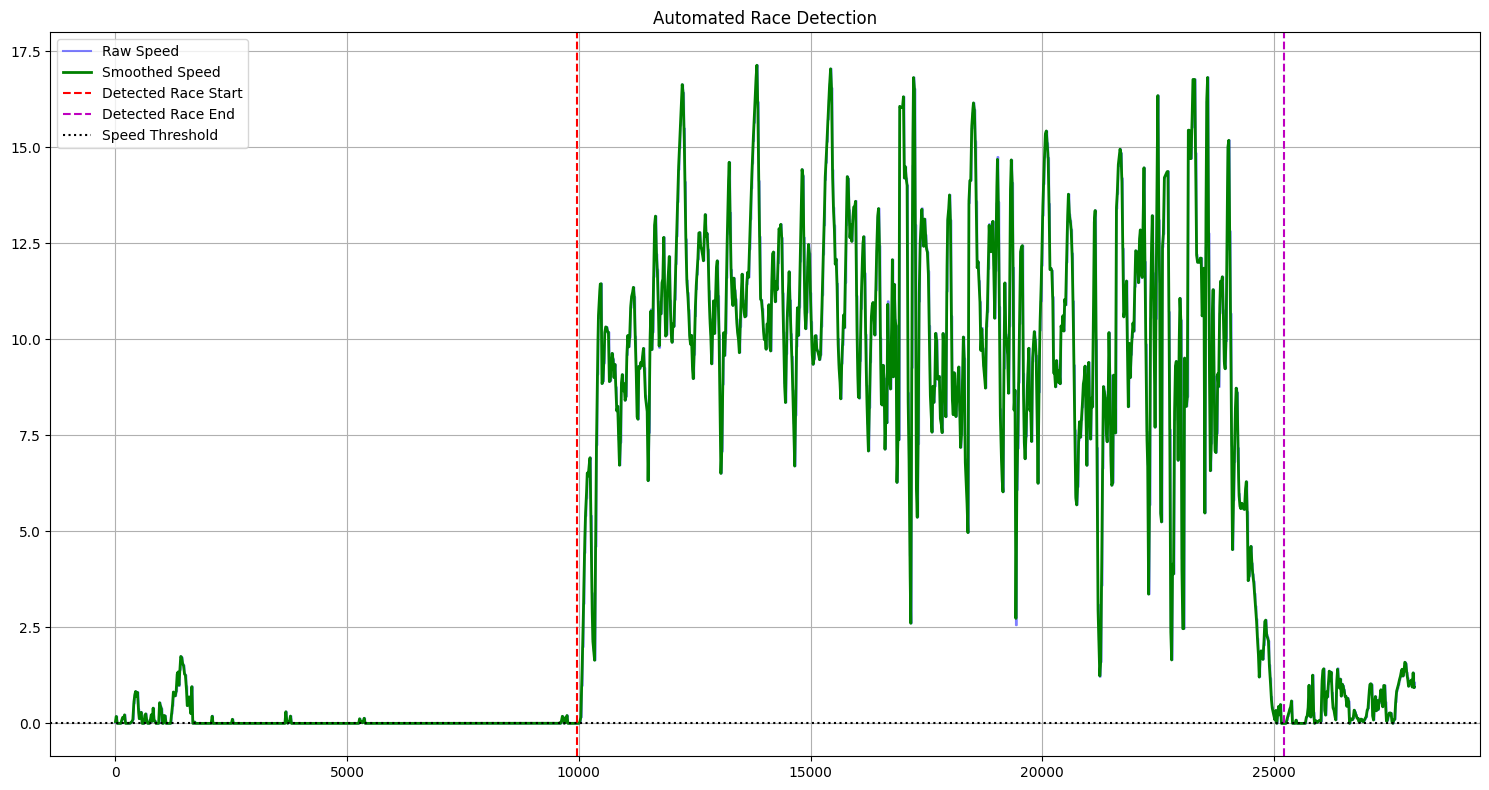

Extracted race data: 15255 rows


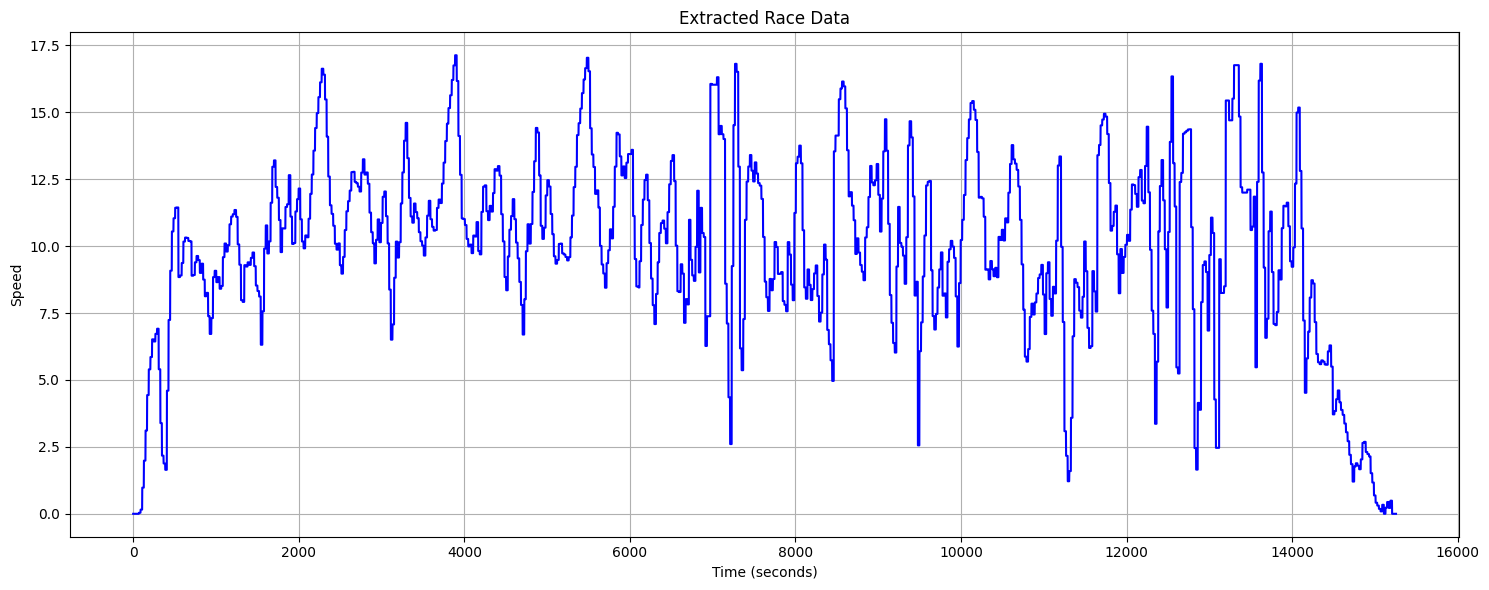

locationLatitude,locationLongitude,locationSpeed,locationCourse,accelerometerAccelerationX,accelerometerAccelerationY,accelerometerAccelerationZ,gyroRotationX,gyroRotationY,gyroRotationZ,motionYaw,motionPitch,motionRoll,loggingTime
str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""30.131845""","""-97.641975""","""0.000000""","""-1.000000""","""0.227234""","""-0.384186""","""0.891815""","""0.005517""","""0.001360""","""0.009478""","""-0.314289""","""-0.419538""","""2.763564""","""2025-09-18T18:00:37.590-05:00"""
"""30.131845""","""-97.641975""","""0.000000""","""-1.000000""","""0.218826""","""-0.391144""","""0.891876""","""0.006388""","""-0.009470""","""0.015693""","""-0.315012""","""-0.419500""","""2.763202""","""2025-09-18T18:00:37.640-05:00"""
"""30.131845""","""-97.641975""","""0.000000""","""-1.000000""","""0.223022""","""-0.390213""","""0.885315""","""0.005418""","""-0.001857""","""0.002187""","""-0.315793""","""-0.419457""","""2.762526""","""2025-09-18T18:00:37.693-05:00"""
"""30.131845""","""-97.641975""","""0.000000""","""-1.000000""","""0.225784""","""-0.385773""","""0.893646""","""-0.001928""","""0.002155""","""0.003674""","""-0.316032""","""-0.419684""","""2.762412""","""2025-09-18T18:00:37.740-05:00"""
"""30.131845""","""-97.641975""","""0.000000""","""-1.000000""","""0.225372""","""-0.387558""","""0.888931""","""-0.005696""","""-0.001972""","""0.001950""","""-0.316016""","""-0.419495""","""2.762515""","""2025-09-18T18:00:37.791-05:00"""


In [14]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector

def identify_race_boundaries(driving_df):
    """
    Use interactive visualization to identify race start and end points
    based on speed patterns and allow manual selection.
    """
    # Extract speed data and time
    speed = driving_df['locationSpeed'].to_numpy()
    
    # Convert to float if needed
    if speed.dtype == 'object':
        speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in speed])
    
    # Create a time axis
    if 'time_seconds' in driving_df.columns:
        time = driving_df['time_seconds'].to_numpy()
        if time.dtype == 'object':
            time = np.array([float(t) if t is not None and t != '' else 0.0 for t in time])
    else:
        time = np.arange(len(speed))
    
    # Create plot for manual selection
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(time, speed, 'b-', linewidth=1)
    ax.set_title('Select Race Start and End (Drag to Select)')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Speed')
    ax.grid(True)
    
    # Create span selector for manual selection
    span = SpanSelector(
        ax,
        onselect=lambda min_, max_: None,  # We'll use the span directly
        direction="horizontal",
        props=dict(alpha=0.3, facecolor="tab:blue"),
        interactive=True,
        drag_from_anywhere=True
    )
    
    plt.tight_layout()
    plt.show()
    
    # After the plot is closed, get the selected range
    race_start_idx = np.searchsorted(time, span.extents[0])
    race_end_idx = np.searchsorted(time, span.extents[1])
    
    print(f"Selected race segment: {span.extents[0]:.2f}s to {span.extents[1]:.2f}s")
    print(f"This corresponds to data points {race_start_idx} to {race_end_idx}")
    
    return race_start_idx, race_end_idx

def analyze_speed_patterns(driving_df):
    """
    Automatically identify likely race start/end by analyzing speed patterns
    """
    # Extract speed data
    speed = driving_df['locationSpeed'].to_numpy()
    
    # Convert to float if needed
    if speed.dtype == 'object':
        speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in speed])
    
    # Apply smoothing to reduce noise
    window_size = 20
    smoothed_speed = np.convolve(speed, np.ones(window_size)/window_size, mode='valid')
    
    # Calculate moving standard deviation of speed
    rolling_std = np.array([np.std(speed[max(0, i-window_size):i+window_size]) 
                            for i in range(len(speed))])
    
    # Look for where speed first exceeds a threshold (race start)
    speed_threshold = np.percentile(smoothed_speed, 25)  # 25th percentile as threshold
    active_indices = np.where(smoothed_speed > speed_threshold)[0]
    
    # Find the first sustained period of activity
    if len(active_indices) > 0:
        activity_gaps = np.diff(active_indices)
        large_gaps = np.where(activity_gaps > 100)[0]
        
        # Identify activity segments
        segments = []
        last_idx = 0
        for gap_idx in large_gaps:
            segments.append((active_indices[last_idx], active_indices[gap_idx]))
            last_idx = gap_idx + 1
            
        if last_idx < len(active_indices):
            segments.append((active_indices[last_idx], active_indices[-1]))
        
        # Get the longest segment (likely the main race)
        if segments:
            main_segment = max(segments, key=lambda x: x[1] - x[0])
            race_start_idx, race_end_idx = main_segment
            
            # Adjust to include a bit before and after
            race_start_idx = max(0, race_start_idx - 50)
            race_end_idx = min(len(speed) - 1, race_end_idx + 50)
            
            # Plot results for verification
            plt.figure(figsize=(15, 8))
            plt.plot(speed, 'b-', alpha=0.5, label='Raw Speed')
            plt.plot(smoothed_speed, 'g-', linewidth=2, label='Smoothed Speed')
            plt.axvline(x=race_start_idx, color='r', linestyle='--', label='Detected Race Start')
            plt.axvline(x=race_end_idx, color='m', linestyle='--', label='Detected Race End')
            plt.axhline(y=speed_threshold, color='k', linestyle=':', label='Speed Threshold')
            plt.title('Automated Race Detection')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            
            return race_start_idx, race_end_idx
    
    # If automatic detection fails
    print("Automatic detection couldn't identify clear race boundaries.")
    return None, None

def extract_race_data(driving_df):
    """
    Main function to identify and extract race data
    """
    # First try automatic detection
    print("Attempting automatic race detection...")
    race_start_idx, race_end_idx = analyze_speed_patterns(driving_df)
    
    # If automatic detection fails or user wants manual selection
    if race_start_idx is None or input("Use manual selection instead? (y/n): ").lower() == 'y':
        print("Please select the race portion in the graph (click and drag)...")
        race_start_idx, race_end_idx = identify_race_boundaries(driving_df)
    
    # Extract the race portion of the data
    race_df = driving_df.slice(race_start_idx, race_end_idx - race_start_idx)
    
    print(f"Extracted race data: {race_df.height} rows")
    
    # Plot the extracted race data
    plt.figure(figsize=(15, 6))
    
    if 'time_seconds' in race_df.columns:
        time = race_df['time_seconds'].to_numpy()
        if time.dtype == 'object':
            time = np.array([float(t) if t is not None and t != '' else 0.0 for t in time])
        time = time - time[0]  # Reset to start at 0
    else:
        time = np.arange(race_df.height)
        
    speed = race_df['locationSpeed'].to_numpy()
    if speed.dtype == 'object':
        speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in speed])
        
    plt.plot(time, speed, 'b-')
    plt.title('Extracted Race Data')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Speed')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return race_df

# Call the function to extract race data
race_df = extract_race_data(driving_df)
race_df.head()

## Identify laps

In [19]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from scipy.signal import find_peaks
from matplotlib.widgets import RectangleSelector
import matplotlib.patches as patches

def detect_pit_and_laps(race_df, visualize=True):
    """
    Detect pit lane and lap segments for karting with a pit entry/exit.
    
    Args:
        race_df: Polars DataFrame containing the race data
        visualize: Whether to show visualization
        
    Returns:
        lap_segments: List of (start_idx, end_idx) tuples for each lap
        pit_segments: List of (start_idx, end_idx) tuples for pit lane segments
    """
    # Extract coordinates and speed
    lat = race_df['locationLatitude'].to_numpy()
    lon = race_df['locationLongitude'].to_numpy()
    speed = race_df['locationSpeed'].to_numpy()
    
    # Convert to float if needed
    if lat.dtype == 'object':
        lat = np.array([float(x) if x is not None and x != '' else 0.0 for x in lat])
    if lon.dtype == 'object':
        lon = np.array([float(x) if x is not None and x != '' else 0.0 for x in lon])
    if speed.dtype == 'object':
        speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in speed])
    
    # Get time data
    if 'time_seconds' in race_df.columns:
        time = race_df['time_seconds'].to_numpy()
        if time.dtype == 'object':
            time = np.array([float(t) if t is not None and t != '' else 0.0 for t in time])
    else:
        time = np.arange(len(lat))
    
    # Step 1: Interactive selection of the pit lane and start/finish line
    if visualize:
        fig, ax = plt.subplots(figsize=(15, 12))
        track = ax.plot(lon, lat, 'b-', linewidth=1.5, alpha=0.7)[0]
        
        # Color the track by speed
        points = np.array([lon, lat]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        # Create line segments colored by speed
        from matplotlib.collections import LineCollection
        norm = plt.Normalize(speed.min(), speed.max())
        lc = LineCollection(segments, cmap='viridis', norm=norm)
        lc.set_array(speed)
        lc.set_linewidth(2)
        line = ax.add_collection(lc)
        fig.colorbar(line, ax=ax, label='Speed')
        
        # Initialize selections
        pit_coords = []
        start_finish_coords = []
        
        # Rectangle for pit lane selection
        pit_rect = None
        sf_line = None
        
        def on_pit_select(eclick, erelease):
            """Callback for pit lane selection"""
            nonlocal pit_rect
            x1, y1 = eclick.xdata, eclick.ydata
            x2, y2 = erelease.xdata, erelease.ydata
            
            # Remove previous rectangle if it exists
            if pit_rect:
                pit_rect.remove()
            
            # Create a new rectangle
            pit_rect = patches.Rectangle(
                (min(x1, x2), min(y1, y2)), 
                abs(x2-x1), abs(y2-y1),
                linewidth=2, edgecolor='r', facecolor='r', alpha=0.3
            )
            ax.add_patch(pit_rect)
            
            # Store pit lane coordinates
            pit_coords.clear()
            pit_coords.extend([min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2)])
            
            ax.set_title('Pit lane selected. Now select the start/finish line (drag across track)')
            plt.draw()
        
        def on_sf_select(eclick, erelease):
            """Callback for start/finish line selection"""
            nonlocal sf_line
            x1, y1 = eclick.xdata, eclick.ydata
            x2, y2 = erelease.xdata, erelease.ydata
            
            # Remove previous line if it exists
            if sf_line:
                sf_line.remove()
            
            # Create a new line
            sf_line = ax.plot([x1, x2], [y1, y2], 'g-', linewidth=3)[0]
            
            # Store start/finish coordinates
            start_finish_coords.clear()
            start_finish_coords.extend([x1, y1, x2, y2])
            
            ax.set_title('Start/finish line selected. Close the plot to continue.')
            plt.draw()
        
        # First, select the pit lane area
        ax.set_title('Select the pit lane area (drag a box)')
        pit_selector = RectangleSelector(
            ax, on_pit_select, useblit=True,
            button=[1],  # Left mouse button
            minspanx=5, minspany=5,
            spancoords='pixels',
            interactive=True
        )
        
        # Wait for pit selection
        plt.show(block=False)
        input("After selecting pit lane, press Enter to continue to start/finish selection...")
        
        # Now select the start/finish line
        ax.set_title('Select the start/finish line (drag across track)')
        sf_selector = RectangleSelector(
            ax, on_sf_select, useblit=True,
            button=[1],  # Left mouse button
            minspanx=5, minspany=5,
            spancoords='pixels',
            interactive=True
        )
        
        plt.show(block=True)
        
        # Check if selections were made
        if not pit_coords or not start_finish_coords:
            print("Selection was not completed. Using automatic detection instead.")
            # Fall back to automatic detection
        else:
            print("Using manual selections for pit lane and start/finish line.")
    
    # If we don't have manual selections or visualization is off, try automatic detection
    if not visualize or not pit_coords:
        print("Attempting automatic pit lane detection...")
        # Find areas with consistently low speed
        low_speed_threshold = np.percentile(speed, 25)
        low_speed_indices = np.where(speed < low_speed_threshold)[0]
        
        # Cluster the low-speed points to find the pit lane
        if len(low_speed_indices) > 10:
            low_speed_coords = np.column_stack([lon[low_speed_indices], lat[low_speed_indices]])
            
            # Use DBSCAN to cluster low-speed points
            clustering = DBSCAN(eps=0.0001, min_samples=10).fit(low_speed_coords)
            
            if len(set(clustering.labels_)) > 1:  # If we found clusters
                # Find the largest cluster (likely the pit lane)
                largest_cluster = max(set(clustering.labels_), key=list(clustering.labels_).count)
                if largest_cluster >= 0:  # Ignore noise points (-1)
                    pit_points = low_speed_coords[clustering.labels_ == largest_cluster]
                    
                    # Create a bounding box for the pit lane
                    pit_coords = [
                        np.min(pit_points[:, 0]), np.min(pit_points[:, 1]),
                        np.max(pit_points[:, 0]), np.max(pit_points[:, 1])
                    ]
                    print("Pit lane detected automatically.")
                else:
                    print("No valid pit lane cluster found.")
            else:
                print("No distinct clusters found for pit lane.")
        else:
            print("Not enough low-speed points to detect pit lane.")
    
    if not pit_coords:
        print("Pit lane detection failed. Using entire track.")
        # Use the entire track bounds as a fallback
        pit_coords = [lon.min(), lat.min(), lon.max(), lat.max()]
    
    # Step 2: Identify pit lane entries and exits
    in_pit = np.zeros(len(lon), dtype=bool)
    
    # Check which points are in the pit lane area
    for i in range(len(lon)):
        in_pit[i] = (
            lon[i] >= pit_coords[0] and lon[i] <= pit_coords[2] and
            lat[i] >= pit_coords[1] and lat[i] <= pit_coords[3]
        )
    
    # Find transitions between track and pit
    pit_transitions = np.diff(in_pit.astype(int))
    pit_entries = np.where(pit_transitions == 1)[0] + 1  # +1 because diff reduces length by 1
    pit_exits = np.where(pit_transitions == -1)[0] + 1
    
    # Ensure we have matching entries and exits
    if len(pit_entries) == 0 and len(pit_exits) == 0:
        print("No pit lane entries/exits detected. Assuming entire session is on track.")
        pit_segments = []
        lap_segments = [(0, len(lon)-1)]
    else:
        # Handle cases where we start in the pit or end in the pit
        if (len(pit_entries) > len(pit_exits)) or (len(pit_entries) == len(pit_exits) and in_pit[0]):
            # Started in pit, add a virtual exit at the beginning
            pit_exits = np.insert(pit_exits, 0, 0)
        if (len(pit_exits) > len(pit_entries)) or (len(pit_entries) == len(pit_exits) and in_pit[-1]):
            # Ended in pit, add a virtual entry at the end
            pit_entries = np.append(pit_entries, len(lon)-1)
        
        # Create segments for pit and on-track
        pit_segments = []
        lap_segments = []
        
        for i in range(min(len(pit_entries), len(pit_exits))):
            if i == 0 and pit_exits[i] > pit_entries[i]:
                # Started in the pit
                pit_segments.append((0, pit_exits[i]))
            elif i < len(pit_entries):
                pit_segments.append((pit_entries[i], pit_exits[i] if i < len(pit_exits) else len(lon)-1))
            
            if i < len(pit_exits):
                if i+1 < len(pit_entries):
                    lap_segments.append((pit_exits[i], pit_entries[i+1]))
                else:
                    lap_segments.append((pit_exits[i], len(lon)-1))
    
    # Step 3: Use start/finish line to split laps if we have manual selection
    if visualize and start_finish_coords and lap_segments:
        sf_x1, sf_y1, sf_x2, sf_y2 = start_finish_coords
        
        # Line equation: ax + by + c = 0
        a = sf_y2 - sf_y1
        b = sf_x1 - sf_x2
        c = sf_x2 * sf_y1 - sf_x1 * sf_y2
        
        # Calculate distance from each point to the line
        distances = np.abs(a * lon + b * lat + c) / np.sqrt(a**2 + b**2)
        
        # Find points close to the line that aren't in the pit
        close_to_line = distances < 0.00005  # Adjust threshold as needed
        on_track = ~in_pit
        sf_crossings = np.where(close_to_line & on_track)[0]
        
        # Filter crossings to ensure they're spaced out (avoid multiple detections)
        min_crossing_gap = 50  # Minimum points between crossings
        filtered_crossings = [sf_crossings[0]] if len(sf_crossings) > 0 else []
        
        for i in range(1, len(sf_crossings)):
            if sf_crossings[i] - filtered_crossings[-1] > min_crossing_gap:
                filtered_crossings.append(sf_crossings[i])
        
        if len(filtered_crossings) > 1:
            print(f"Detected {len(filtered_crossings)} start/finish line crossings")
            
            # Refine lap segments using start/finish crossings
            refined_lap_segments = []
            
            for lap_start, lap_end in lap_segments:
                # Find crossings within this segment
                seg_crossings = [c for c in filtered_crossings if lap_start <= c <= lap_end]
                
                if len(seg_crossings) <= 1:
                    # Not enough crossings to split, keep the original segment
                    refined_lap_segments.append((lap_start, lap_end))
                else:
                    # Split the segment at each crossing
                    for i in range(len(seg_crossings) - 1):
                        refined_lap_segments.append((seg_crossings[i], seg_crossings[i+1]))
            
            lap_segments = refined_lap_segments
    
    # Calculate lap times
    lap_times = []
    for start_idx, end_idx in lap_segments:
        lap_start_time = time[start_idx]
        lap_end_time = time[end_idx]
        lap_time = lap_end_time - lap_start_time
        lap_times.append(lap_time)
    
    # Visualize the final lap and pit segments
    if visualize:
        plt.figure(figsize=(15, 10))
        
        # Plot the track
        plt.plot(lon, lat, 'lightgray', linewidth=1, alpha=0.5)
        
        # Plot pit lane
        pit_x = [pit_coords[0], pit_coords[2], pit_coords[2], pit_coords[0], pit_coords[0]]
        pit_y = [pit_coords[1], pit_coords[1], pit_coords[3], pit_coords[3], pit_coords[1]]
        plt.plot(pit_x, pit_y, 'r-', linewidth=2)
        
        # Plot start/finish line if available
        if start_finish_coords:
            sf_x1, sf_y1, sf_x2, sf_y2 = start_finish_coords
            plt.plot([sf_x1, sf_x2], [sf_y1, sf_y2], 'g-', linewidth=3)
        
        # Plot each lap with a different color
        colors = plt.cm.jet(np.linspace(0, 1, len(lap_segments)))
        for i, (start_idx, end_idx) in enumerate(lap_segments):
            plt.plot(lon[start_idx:end_idx+1], lat[start_idx:end_idx+1], 
                    color=colors[i], linewidth=2, label=f"Lap {i+1} ({lap_times[i]:.2f}s)")
        
        # Plot pit segments
        for i, (start_idx, end_idx) in enumerate(pit_segments):
            plt.plot(lon[start_idx:end_idx+1], lat[start_idx:end_idx+1], 
                    'r-', linewidth=2, alpha=0.7)
        
        plt.title('Track Map with Detected Laps and Pit Lane')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.grid(True)
        plt.legend(loc='best')
        plt.axis('equal')
        plt.tight_layout()
        plt.show()
        
        # Plot lap times
        plt.figure
        

        # Plot lap times
        plt.figure(figsize=(12, 6))
        plt.bar(range(1, len(lap_times)+1), lap_times, color=colors)
        plt.title('Lap Times')
        plt.xlabel('Lap Number')
        plt.ylabel('Time (seconds)')
        plt.grid(True, axis='y')
        plt.tight_layout()
        plt.show()
        
        # Plot speed profile with laps and pit segments marked
        plt.figure(figsize=(15, 6))
        plt.plot(time, speed, 'b-', alpha=0.7)
        
        # Mark lap segments
        for i, (start_idx, end_idx) in enumerate(lap_segments):
            plt.axvspan(time[start_idx], time[end_idx], alpha=0.2, color=colors[i])
            plt.text(time[start_idx] + (time[end_idx]-time[start_idx])/2, np.max(speed)*0.9,
                    f"Lap {i+1}", ha='center')
        
        # Mark pit segments
        for start_idx, end_idx in pit_segments:
            plt.axvspan(time[start_idx], time[end_idx], alpha=0.3, color='red')
        
        plt.title('Speed Profile with Lap and Pit Segments')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Speed')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    # Print lap summary
    print(f"Detected {len(lap_segments)} laps and {len(pit_segments)} pit segments")
    for i, ((start_idx, end_idx), lap_time) in enumerate(zip(lap_segments, lap_times)):
        print(f"Lap {i+1}: {lap_time:.2f} seconds (indices {start_idx}-{end_idx})")
    
    return lap_segments, pit_segments


def analyze_laps(race_df, lap_segments):
    """
    Analyze each lap for detailed performance metrics
    
    Args:
        race_df: DataFrame containing race data
        lap_segments: List of (start_idx, end_idx) tuples for each lap
        
    Returns:
        Dictionary of lap metrics
    """
    lap_metrics = {}
    
    # Extract speed and time
    speed = race_df['locationSpeed'].to_numpy()
    if speed.dtype == 'object':
        speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in speed])
    
    if 'time_seconds' in race_df.columns:
        time = race_df['time_seconds'].to_numpy()
        if time.dtype == 'object':
            time = np.array([float(t) if t is not None and t != '' else 0.0 for t in time])
    else:
        time = np.arange(len(speed))
    
    # Extract acceleration data if available
    accel_x = race_df['accelerometerAccelerationX'].to_numpy() if 'accelerometerAccelerationX' in race_df.columns else None
    accel_y = race_df['accelerometerAccelerationY'].to_numpy() if 'accelerometerAccelerationY' in race_df.columns else None
    accel_z = race_df['accelerometerAccelerationZ'].to_numpy() if 'accelerometerAccelerationZ' in race_df.columns else None
    
    # Convert object types if necessary
    if accel_x is not None and accel_x.dtype == 'object':
        accel_x = np.array([float(a) if a is not None and a != '' else 0.0 for a in accel_x])
    if accel_y is not None and accel_y.dtype == 'object':
        accel_y = np.array([float(a) if a is not None and a != '' else 0.0 for a in accel_y])
    if accel_z is not None and accel_z.dtype == 'object':
        accel_z = np.array([float(a) if a is not None and a != '' else 0.0 for a in accel_z])
    
    # Calculate metrics for each lap
    for i, (start_idx, end_idx) in enumerate(lap_segments):
        lap_speed = speed[start_idx:end_idx+1]
        lap_time = time[end_idx] - time[start_idx]
        
        metrics = {
            'lap_time': lap_time,
            'avg_speed': np.mean(lap_speed),
            'max_speed': np.max(lap_speed),
            'min_speed': np.min(lap_speed),
            'speed_range': np.max(lap_speed) - np.min(lap_speed)
        }
        
        # Calculate acceleration metrics if available
        if accel_x is not None and accel_y is not None:
            lap_accel_x = accel_x[start_idx:end_idx+1]
            lap_accel_y = accel_y[start_idx:end_idx+1]
            
            # Calculate lateral G forces
            lateral_g = lap_accel_x
            longitudinal_g = lap_accel_y
            
            # Calculate combined G force
            combined_g = np.sqrt(lap_accel_x**2 + lap_accel_y**2)
            if accel_z is not None:
                lap_accel_z = accel_z[start_idx:end_idx+1]
                combined_g = np.sqrt(lap_accel_x**2 + lap_accel_y**2 + lap_accel_z**2)
            
            metrics.update({
                'max_lateral_g': np.max(np.abs(lateral_g)),
                'max_longitudinal_g': np.max(np.abs(longitudinal_g)),
                'max_combined_g': np.max(combined_g),
                'avg_combined_g': np.mean(combined_g)
            })
        
        lap_metrics[i+1] = metrics
    
    # Identify best lap
    best_lap = min(lap_metrics.keys(), key=lambda k: lap_metrics[k]['lap_time'])
    
    # Print summary
    print(f"\nLap Analysis Summary:")
    print(f"Best lap: Lap {best_lap} ({lap_metrics[best_lap]['lap_time']:.2f}s)")
    
    print("\nLap Metrics:")
    print(f"{'Lap':<5} {'Time(s)':<10} {'Avg Speed':<10} {'Max Speed':<10} {'Min Speed':<10}")
    print("-" * 50)
    for lap_num, metrics in lap_metrics.items():
        print(f"{lap_num:<5} {metrics['lap_time']:<10.2f} {metrics['avg_speed']:<10.2f} "
            f"{metrics['max_speed']:<10.2f} {metrics['min_speed']:<10.2f}")
    
    # Visualize lap comparisons
    plt.figure(figsize=(15, 8))
    
    # Bar chart of lap times
    plt.subplot(2, 2, 1)
    lap_nums = list(lap_metrics.keys())
    lap_times = [lap_metrics[k]['lap_time'] for k in lap_nums]
    bars = plt.bar(lap_nums, lap_times)
    bars[best_lap-1].set_color('green')
    plt.title('Lap Times')
    plt.xlabel('Lap Number')
    plt.ylabel('Time (seconds)')
    plt.grid(True, axis='y')
    
    # Bar chart of average speeds
    plt.subplot(2, 2, 2)
    avg_speeds = [lap_metrics[k]['avg_speed'] for k in lap_nums]
    bars = plt.bar(lap_nums, avg_speeds)
    bars[best_lap-1].set_color('green')
    plt.title('Average Speed')
    plt.xlabel('Lap Number')
    plt.ylabel('Speed')
    plt.grid(True, axis='y')
    
    # Bar chart of max speeds
    plt.subplot(2, 2, 3)
    max_speeds = [lap_metrics[k]['max_speed'] for k in lap_nums]
    bars = plt.bar(lap_nums, max_speeds)
    bars[best_lap-1].set_color('green')
    plt.title('Maximum Speed')
    plt.xlabel('Lap Number')
    plt.ylabel('Speed')
    plt.grid(True, axis='y')
    
    # Bar chart of G-forces if available
    plt.subplot(2, 2, 4)
    if 'max_combined_g' in lap_metrics[lap_nums[0]]:
        max_gs = [lap_metrics[k]['max_combined_g'] for k in lap_nums]
        bars = plt.bar(lap_nums, max_gs)
        bars[best_lap-1].set_color('green')
        plt.title('Maximum G-Force')
        plt.xlabel('Lap Number')
        plt.ylabel('G')
        plt.grid(True, axis='y')
    else:
        plt.text(0.5, 0.5, 'G-Force data not available', ha='center', va='center')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Compare best lap to others
    plt.figure(figsize=(15, 6))
    
    best_start, best_end = lap_segments[best_lap-1]
    best_lap_length = best_end - best_start
    
    # Normalize all laps to the same length for comparison
    normalized_speeds = {}
    
    for i, (start_idx, end_idx) in enumerate(lap_segments):
        lap_num = i + 1
        lap_speed = speed[start_idx:end_idx+1]
        
        # Resample to match best lap length
        resampled = np.interp(
            np.linspace(0, 1, best_lap_length),
            np.linspace(0, 1, len(lap_speed)),
            lap_speed
        )
        
        normalized_speeds[lap_num] = resampled
    
    # Plot normalized speed traces
    for lap_num, lap_speed in normalized_speeds.items():
        alpha = 1.0 if lap_num == best_lap else 0.5
        linestyle = '-' if lap_num == best_lap else '--'
        linewidth = 2.5 if lap_num == best_lap else 1.5
        plt.plot(lap_speed, alpha=alpha, linestyle=linestyle, linewidth=linewidth, 
                label=f"Lap {lap_num}{' (Best)' if lap_num == best_lap else ''}")
    
    plt.title('Speed Comparison (Normalized by Distance)')
    plt.xlabel('Distance (Normalized)')
    plt.ylabel('Speed')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return lap_metrics, best_lap

def compare_best_worst_laps(race_df, lap_segments, lap_metrics):
    """
    Compare the best and worst laps in detail
    """
    if len(lap_metrics) < 2:
        print("Need at least two laps for comparison")
        return
    
    # Find best and worst laps
    best_lap = min(lap_metrics.keys(), key=lambda k: lap_metrics[k]['lap_time'])
    worst_lap = max(lap_metrics.keys(), key=lambda k: lap_metrics[k]['lap_time'])
    
    if best_lap == worst_lap:
        print("Only one valid lap detected")
        return
        
    best_start, best_end = lap_segments[best_lap-1]
    worst_start, worst_end = lap_segments[worst_lap-1]
    
    # Get data for both laps
    best_df = race_df.slice(best_start, best_end - best_start)
    worst_df = race_df.slice(worst_start, worst_end - worst_start)
    
    # Extract coordinates for track map
    best_lat = best_df['locationLatitude'].to_numpy()
    best_lon = best_df['locationLongitude'].to_numpy()
    worst_lat = worst_df['locationLatitude'].to_numpy()
    worst_lon = worst_df['locationLongitude'].to_numpy()
    
    # Convert to float if needed
    if best_lat.dtype == 'object':
        best_lat = np.array([float(x) if x is not None and x != '' else 0.0 for x in best_lat])
    if best_lon.dtype == 'object':
        best_lon = np.array([float(x) if x is not None and x != '' else 0.0 for x in best_lon])
    if worst_lat.dtype == 'object':
        worst_lat = np.array([float(x) if x is not None and x != '' else 0.0 for x in worst_lat])
    if worst_lon.dtype == 'object':
        worst_lon = np.array([float(x) if x is not None and x != '' else 0.0 for x in worst_lon])
    
    # Extract speed data
    best_speed = best_df['locationSpeed'].to_numpy()
    worst_speed = worst_df['locationSpeed'].to_numpy()
    
    if best_speed.dtype == 'object':
        best_speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in best_speed])
    if worst_speed.dtype == 'object':
        worst_speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in worst_speed])
    
    # Create visualization
    plt.figure(figsize=(15, 10))
    
    # Track map comparison
    plt.subplot(2, 1, 1)
    plt.plot(best_lon, best_lat, 'g-', linewidth=2.5, label=f"Best Lap ({lap_metrics[best_lap]['lap_time']:.2f}s)")
    plt.plot(worst_lon, worst_lat, 'r-', linewidth=2.5, label=f"Worst Lap ({lap_metrics[worst_lap]['lap_time']:.2f}s)")
    plt.title('Racing Line Comparison')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(loc='best')
    plt.grid(True)
    plt.axis('equal')
    
    # Speed profile comparison (normalized by distance)
    plt.subplot(2, 1, 2)
    
    # Normalize by distance
    best_norm = np.linspace(0, 1, len(best_speed))
    worst_norm = np.linspace(0, 1, len(worst_speed))
    
    # Common x axis
    common_x = np.linspace(0, 1, 500)
    
    # Interpolate speed to common x axis
    best_interp = np.interp(common_x, best_norm, best_speed)
    worst_interp = np.interp(common_x, worst_norm, worst_speed)
    
    # Calculate difference
    speed_diff = best_interp - worst_interp
    
    plt.plot(common_x, best_interp, 'g-', linewidth=2, label='Best Lap')
    plt.plot(common_x, worst_interp, 'r-', linewidth=2, label='Worst Lap')
    plt.plot(common_x, speed_diff, 'b--', linewidth=1.5, label='Difference (Best - Worst)')
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    plt.title('Speed Comparison (Normalized by Distance)')
    plt.xlabel('Normalized Distance')
    plt.ylabel('Speed')
    plt.legend(loc='best')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Find key performance differences
    # 1. Calculate where the biggest speed differences occur
    diff_sections = []
    window_size = 20  # Size of rolling window to detect consistent differences
    
    for i in range(len(common_x) - window_size):
        avg_diff = np.mean(speed_diff[i:i+window_size])
        if abs(avg_diff) > 2.0:  # Significant difference threshold
            section_start = i / len(common_x)
            section_end = (i + window_size) / len(common_x)
            diff_sections.append((section_start, section_end, avg_diff))
    
    # Merge nearby sections
    if diff_sections:
        merged_sections = [diff_sections[0]]
        for section in diff_sections[1:]:
            last_section = merged_sections[-1]
            # If this section is close to the last one and has the same sign of difference
            if (section[0] - last_section[1] < 0.05 and 
                (section[2] > 0) == (last_section[2] > 0)):
                # Merge them
                merged_sections[-1] = (
                    last_section[0], 
                    section[1], 
                    (last_section[2] + section[2]) / 2
                )
            else:
                merged_sections.append(section)
        
        # Print key differences
        print("\nKey Performance Differences (Best vs Worst):")
        for i, (start, end, diff) in enumerate(merged_sections):
            percent_start = start * 100
            percent_end = end * 100
            better_worse = "faster" if diff > 0 else "slower"
            print(f"Section {i+1}: {percent_start:.1f}%-{percent_end:.1f}% - Best lap is {abs(diff):.2f} units {better_worse}")
    
    # 2. Calculate cornering differences if G-force data is available
    if ('accelerometerAccelerationX' in best_df.columns and 
        'accelerometerAccelerationY' in best_df.columns):
        
        # Extract G-force data
        best_lat_g = best_df['accelerometerAccelerationX'].to_numpy()
        best_long_g = best_df['accelerometerAccelerationY'].to_numpy()
        worst_lat_g = worst_df['accelerometerAccelerationX'].to_numpy()
        worst_long_g = worst_df['accelerometerAccelerationY'].to_numpy()
        
        # Convert to float if needed
        if best_lat_g.dtype == 'object':
            best_lat_g = np.array([float(g) if g is not None and g != '' else 0.0 for g in best_lat_g])
        if best_long_g.dtype == 'object':
            best_long_g = np.array([float(g) if g is not None and g != '' else 0.0 for g in best_long_g])
        if worst_lat_g.dtype == 'object':
            worst_lat_g = np.array([float(g) if g is not None and g != '' else 0.0 for g in worst_lat_g])
        if worst_long_g.dtype == 'object':
            worst_long_g = np.array([float(g) if g is not None and g != '' else 0.0 for g in worst_long_g])
        
        # Create G-force scatter plot
        plt.figure(figsize=(10, 10))
        
        plt.scatter(best_lat_g, best_long_g, color='green', alpha=0.5, s=10, label='Best Lap')
        plt.scatter(worst_lat_g, worst_long_g, color='red', alpha=0.5, s=10, label='Worst Lap')
        
        # Draw G circles
        theta = np.linspace(0, 2*np.pi, 100)
        for r in [0.5, 1.0, 1.5, 2.0]:
            plt.plot(r*np.cos(theta), r*np.sin(theta), 'b-', alpha=0.3)
            plt.text(r, 0, f"{r}G", ha='center', va='bottom', alpha=0.7)
        
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        
        plt.title('G-Force Comparison')
        plt.xlabel('Lateral G-Force')
        plt.ylabel('Longitudinal G-Force')
        plt.grid(True)
        plt.axis('equal')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # Calculate G-force utilization
        best_total_g = np.sqrt(best_lat_g**2 + best_long_g**2)
        worst_total_g = np.sqrt(worst_lat_g**2 + worst_long_g**2)
        
        print("\nG-Force Utilization:")
        print(f"Best Lap - Average G: {np.mean(best_total_g):.2f}, Max G: {np.max(best_total_g):.2f}")
        print(f"Worst Lap - Average G: {np.mean(worst_total_g):.2f}, Max G: {np.max(worst_total_g):.2f}")
        
        # Cornering analysis
        best_corners = []
        worst_corners = []
        
        # Define a corner as a section with sustained lateral G
        threshold_g = 0.8  # Lateral G threshold for corner detection
        min_duration = 5  # Minimum number of points to be considered a corner
        
        # Detect corners in best lap
        in_corner = False
        corner_start = 0
        for i, g in enumerate(np.abs(best_lat_g)):
            if not in_corner and g > threshold_g:
                in_corner = True
                corner_start = i
            elif in_corner and g < threshold_g:
                in_corner = False
                if i - corner_start >= min_duration:
                    best_corners.append((corner_start, i))
        
        # Detect corners in worst lap
        in_corner = False
        corner_start = 0
        for i, g in enumerate(np.abs(worst_lat_g)):
            if not in_corner and g > threshold_g:
                in_corner = True
                corner_start = i
            elif in_corner and g < threshold_g:
                in_corner = False
                if i - corner_start >= min_duration:
                    worst_corners.append((corner_start, i))
        
        # Compare corner stats if we found corners
        if best_corners and worst_corners:
            print("\nCorner Analysis:")
            print(f"Best Lap: {len(best_corners)} corners detected")
            print(f"Worst Lap: {len(worst_corners)} corners detected")
            
            # Analyze each corner in the best lap
            print("\nBest Lap Corner Details:")
            for i, (start, end) in enumerate(best_corners):
                corner_speed = best_speed[start:end]
                corner_lat_g = best_lat_g[start:end]
                min_speed = np.min(corner_speed)
                max_g = np.max(np.abs(corner_lat_g))
                print(f"Corner {i+1}: Min Speed={min_speed:.2f}, Max Lateral G={max_g:.2f}")
            
            # Analyze each corner in the worst lap
            print("\nWorst Lap Corner Details:")
            for i, (start, end) in enumerate(worst_corners):
                corner_speed = worst_speed[start:end]
                corner_lat_g = worst_lat_g[start:end]
                min_speed = np.min(corner_speed)
                max_g = np.max(np.abs(corner_lat_g))
                print(f"Corner {i+1}: Min Speed={min_speed:.2f}, Max Lateral G={max_g:.2f}")


def create_dashboard(race_df, lap_segments=None, best_lap_idx=None):
    """
    Create a comprehensive F1-style dashboard for race analysis
    """
    # Extract data
    lat = race_df['locationLatitude'].to_numpy()
    lon = race_df['locationLongitude'].to_numpy()
    speed = race_df['locationSpeed'].to_numpy()
    
    # Convert to float if needed
    if lat.dtype == 'object':
        lat = np.array([float(x) if x is not None and x != '' else 0.0 for x in lat])
    if lon.dtype == 'object':
        lon = np.array([float(x) if x is not None and x != '' else 0.0 for x in lon])
    if speed.dtype == 'object':
        speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in speed])
    
    # Get acceleration data if available
    has_accel = ('accelerometerAccelerationX' in race_df.columns and 
                'accelerometerAccelerationY' in race_df.columns)
    
    if has_accel:
        accel_x = race_df['accelerometerAccelerationX'].to_numpy()
        accel_y = race_df['accelerometerAccelerationY'].to_numpy()
        
        # Convert to float if needed
        if accel_x.dtype == 'object':
            accel_x = np.array([float(a) if a is not None and a != '' else 0.0 for a in accel_x])
        if accel_y.dtype == 'object':
            accel_y = np.array([float(a) if a is not None and a != '' else 0.0 for a in accel_y])
    
    # Create main dashboard figure
    fig = plt.figure(figsize=(20, 12))
    
    # Define grid layout
    if has_accel:
        gs = fig.add_gridspec(3, 3)
    else:
        gs = fig.add_gridspec(2, 2)
    
    # Track map (with speed coloring)
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    
    # Create line segments colored by speed
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Create color-mapped line collection
    from matplotlib.collections import LineCollection
    norm = plt.Normalize(speed.min(), speed.max())
    lc = LineCollection(segments, cmap='viridis', norm=norm)
    lc.set_array(speed)
    lc.set_linewidth(2)
    ax1.add_collection(lc)
    
    # Add colorbar
    cbar = plt.colorbar(lc, ax=ax1, label='Speed')
    
    # Highlight lap segments if provided
    if lap_segments:
        colors = plt.cm.tab10(np.linspace(0, 1, len(lap_segments)))
        for i, (start_idx, end_idx) in enumerate(lap_segments):
            ax1.plot(lon[start_idx:start_idx+1], lat[start_idx:start_idx+1], 
                    'o', markersize=8, color=colors[i])
    
    # Highlight best lap if provided
    if lap_segments and best_lap_idx is not None:
        best_start, best_end = lap_segments[best_lap_idx]
        ax1.plot(lon[best_start:best_end+1], lat[best_start:best_end+1], 
                'g-', linewidth=3, alpha=0.7)
    
    ax1.set_title('Track Map')
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.grid(True)
    ax1.set_aspect('equal')
    
    # Speed trace
    ax2 = fig.add_subplot(gs[2, 0:2])
    
    # Get time data
    if 'time_seconds' in race_df.columns:
        time = race_df['time_seconds'].to_numpy()
        if time.dtype == 'object':
            time = np.array([float(t) if t is not None and t != '' else 0.0 for t in time])
        # Normalize time to start at 0
        time = time - time[0]
    else:
        time = np.arange(len(speed))
    
    ax2.plot(time, speed, 'b-', linewidth=1.5)
    
    # Highlight lap segments if provided
    if lap_segments:
        for i, (start_idx, end_idx) in enumerate(lap_segments):
            color = 'green' if i == best_lap_idx else 'gray'
            alpha = 1.0 if i == best_lap_idx else 0.3
            ax2.axvspan(time[start_idx], time[end_idx], alpha=alpha, color=color)
            
            # Add lap number
            lap_mid_time = (time[start_idx] + time[end_idx]) / 2
            ax2.text(lap_mid_time, np.max(speed) * 0.9, f"L{i+1}", 
                     ha='center', va='center', fontsize=10)
    
    ax2.set_title('Speed Trace')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Speed')
    ax2.grid(True)
    
    # G-Force plot (if acceleration data available)
    if has_accel:
        ax3 = fig.add_subplot(gs[0:2, 2])
        
        # Create G-force scatter plot or heatmap
        h = ax3.hist2d(accel_x, accel_y, bins=50, cmap='hot')
        fig.colorbar(h[3], ax=ax3, label='Count')
        
        # Add G circles
        theta = np.linspace(0, 2*np.pi, 100)
        for r in [0.5, 1.0, 1.5, 2.0]:
            ax3.plot(r*np.cos(theta), r*np.sin(theta), 'b-', alpha=0.3)
            ax3.text(r, 0, f"{r}G", ha='center', va='bottom', alpha=0.7)
        
        ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        
        ax3.set_title('G-Force Distribution')
        ax3.set_xlabel('Lateral G-Force')
        ax3.set_ylabel('Longitudinal G-Force')
        ax3.grid(True)
        ax3.set_aspect('equal')
        
        # Add speed distribution
        ax4 = fig.add_subplot(gs[2, 2])
        ax4.hist(speed, bins=30, color='blue', alpha=0.7)
        ax4.set_title('Speed Distribution')
        ax4.set_xlabel('Speed')
        ax4.set_ylabel('Frequency')
        ax4.grid(True)
    
    plt.tight_layout()
    plt.show()



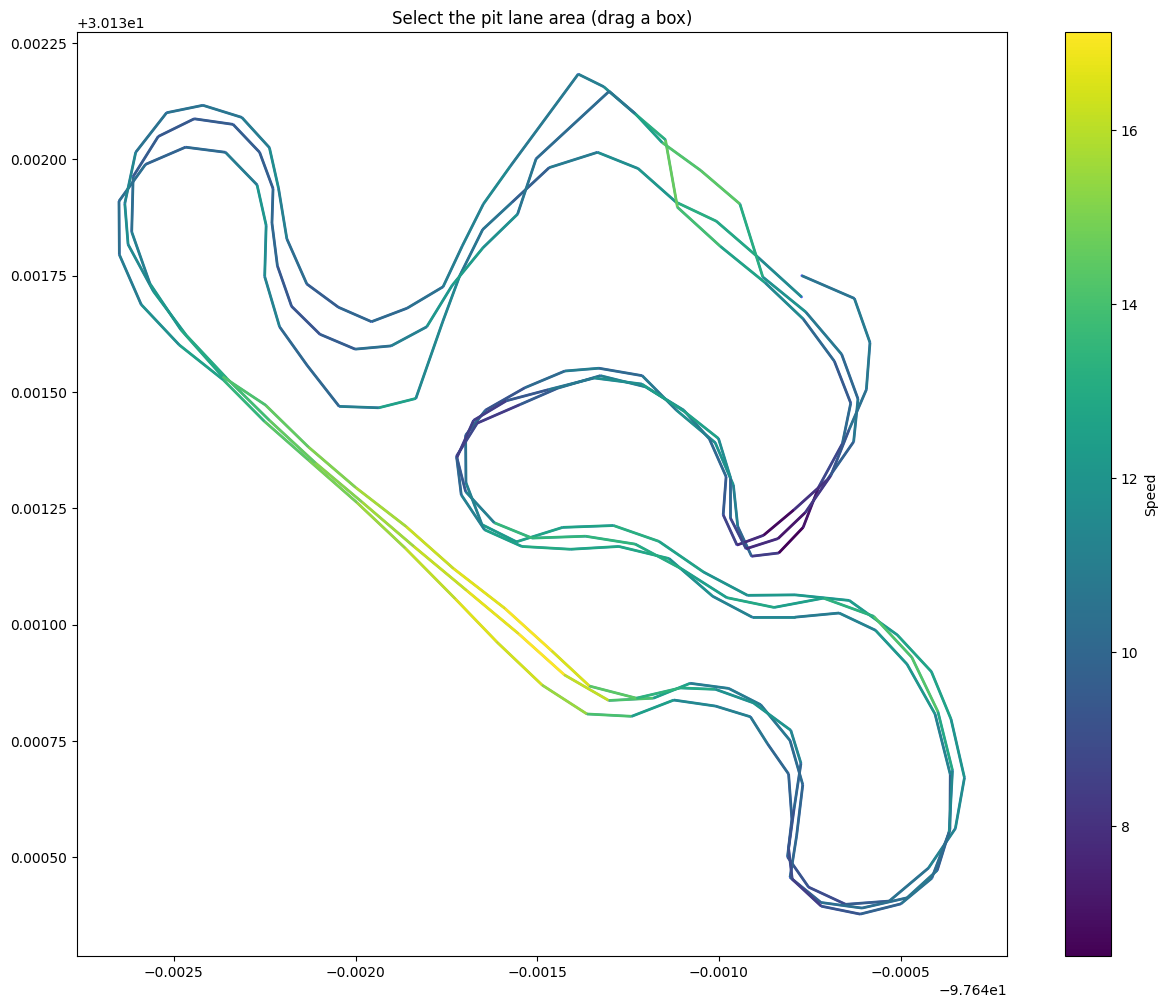

Selection was not completed. Using automatic detection instead.
Attempting automatic pit lane detection...
Pit lane detected automatically.


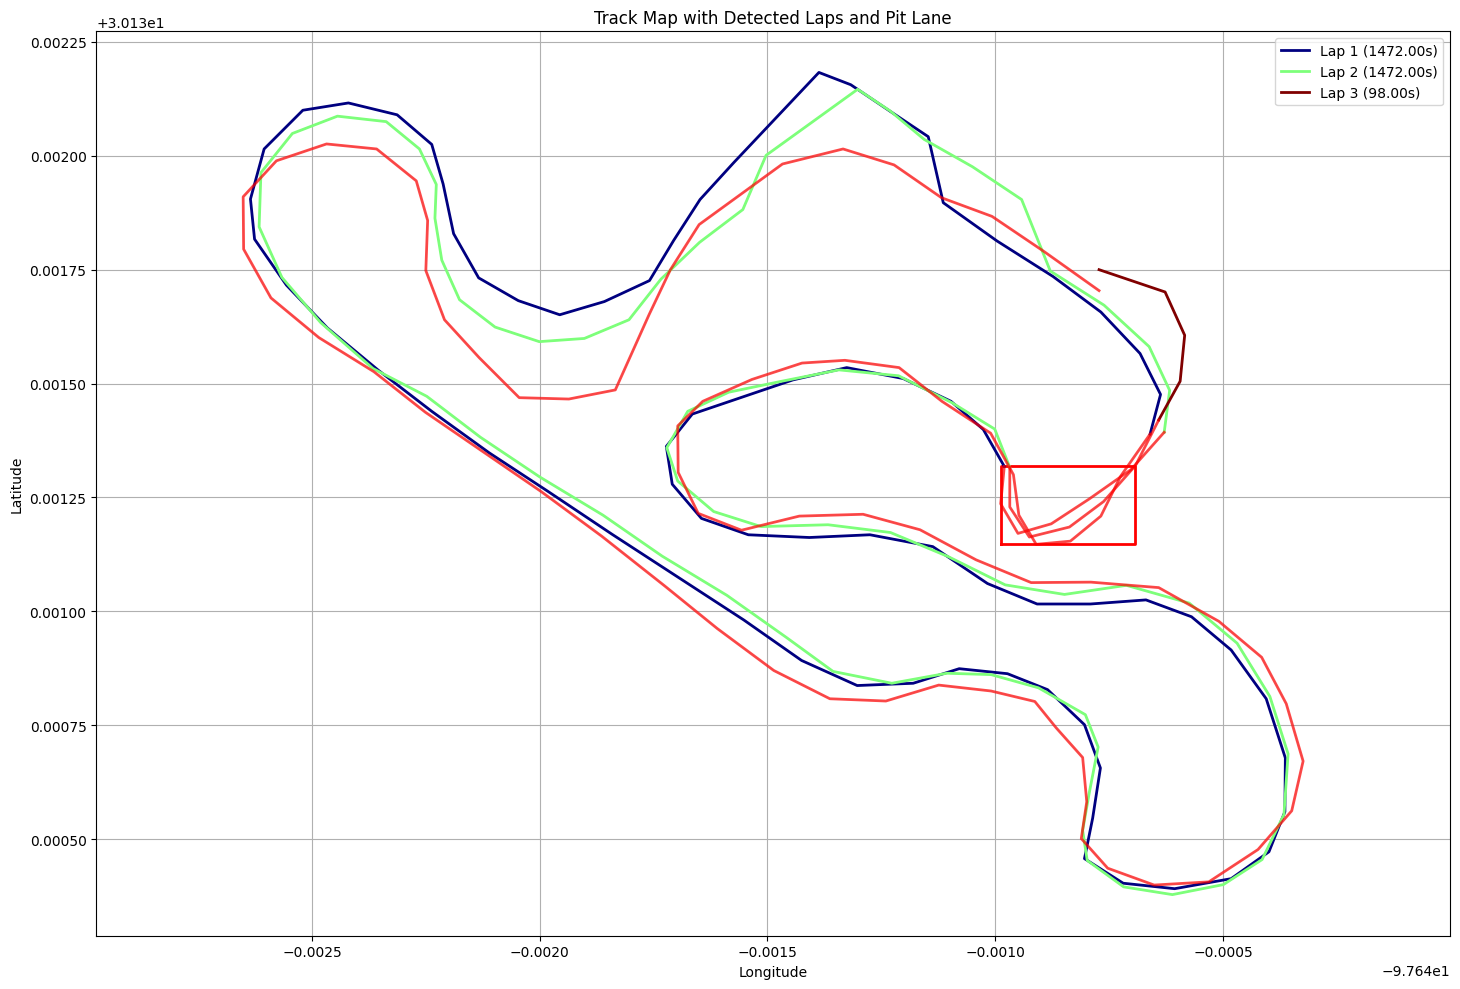

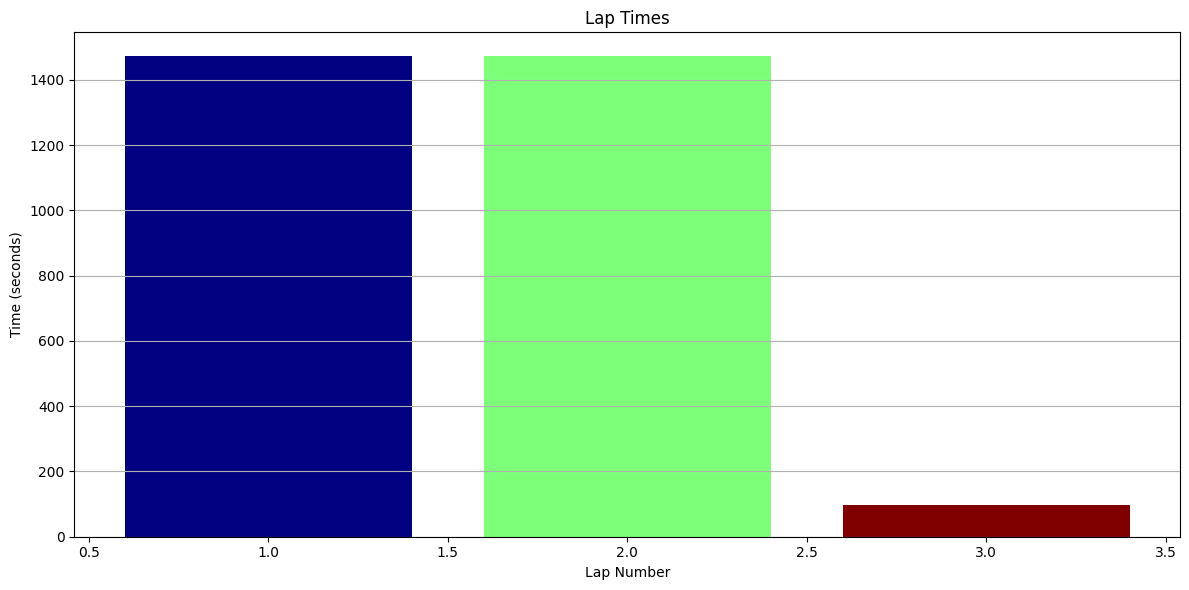

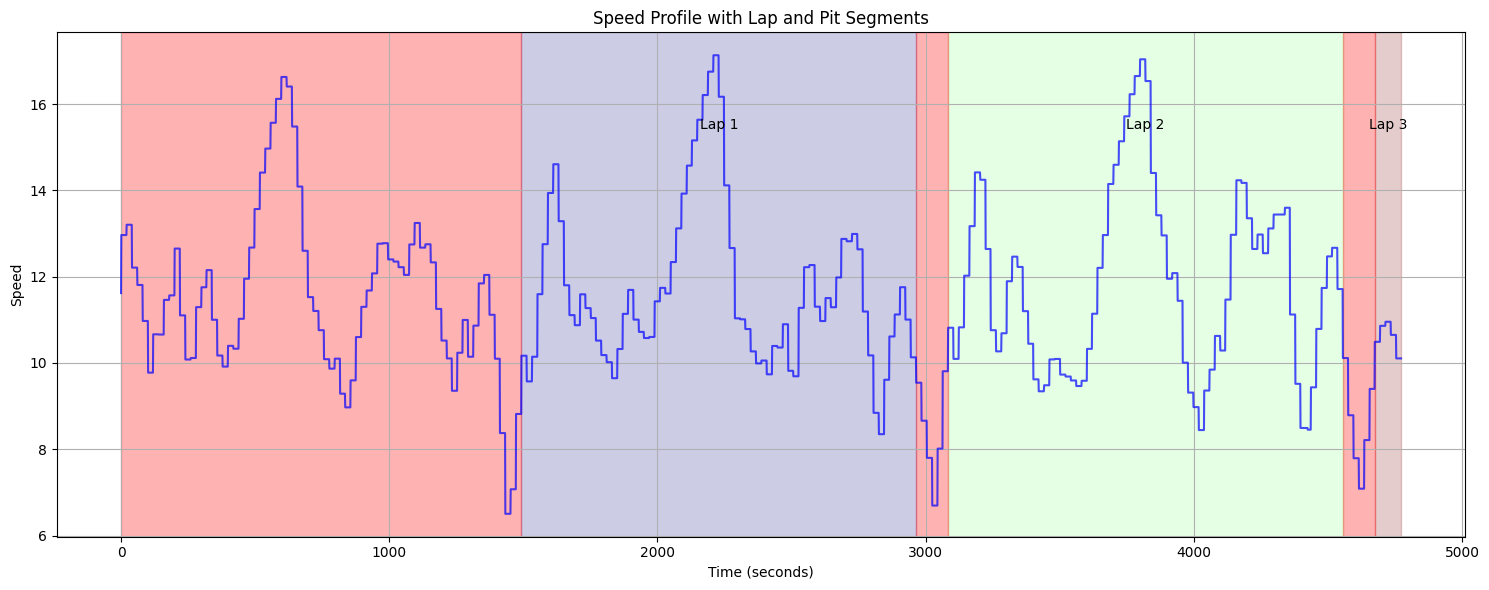

Detected 3 laps and 3 pit segments
Lap 1: 1472.00 seconds (indices 1493-2965)
Lap 2: 1472.00 seconds (indices 3084-4556)
Lap 3: 98.00 seconds (indices 4675-4773)


In [56]:
# Example usage:
lap_segments, pit_segments = detect_pit_and_laps(filtered_df, visualize=True)

In [57]:
import polars as pl
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

def create_interactive_track_visualization_plotly(race_df):
    """
    Create an interactive visualization of the kart track with a time slider using Plotly.
    
    Args:
        race_df: Polars DataFrame containing the race data
    """
    # Extract coordinates and speed
    lat = race_df['locationLatitude'].to_numpy()
    lon = race_df['locationLongitude'].to_numpy()
    speed = race_df['locationSpeed'].to_numpy()
    
    # Convert to float if needed
    if lat.dtype == 'object':
        lat = np.array([float(x) if x is not None and x != '' else 0.0 for x in lat])
    if lon.dtype == 'object':
        lon = np.array([float(x) if x is not None and x != '' else 0.0 for x in lon])
    if speed.dtype == 'object':
        speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in speed])
    
    # Get G-force data if available
    has_accel = ('accelerometerAccelerationX' in race_df.columns and 
                'accelerometerAccelerationY' in race_df.columns)
    
    if has_accel:
        accel_x = race_df['accelerometerAccelerationX'].to_numpy()
        accel_y = race_df['accelerometerAccelerationY'].to_numpy()
        
        # Convert to float if needed
        if accel_x.dtype == 'object':
            accel_x = np.array([float(a) if a is not None and a != '' else 0.0 for a in accel_x])
        if accel_y.dtype == 'object':
            accel_y = np.array([float(a) if a is not None and a != '' else 0.0 for a in accel_y])
            
        # Calculate total G-force
        total_g = np.sqrt(accel_x**2 + accel_y**2)
    else:
        total_g = np.zeros_like(speed)
    
    # Create a DataFrame for Plotly
    time_points = np.arange(len(lat))
    df = pd.DataFrame({
        'time': time_points,
        'lat': lat,
        'lon': lon,
        'speed': speed,
        'g_force': total_g
    })
    
    # Create figure with subplots
    fig = make_subplots(
        rows=2, cols=1,
        row_heights=[0.7, 0.3],
        specs=[[{"type": "scatter"}],  # Changed from scattermapbox to regular scatter
               [{"type": "scatter"}]],
        vertical_spacing=0.05,
        subplot_titles=("Kart Track Map", "Speed Profile")
    )
    
    # Add the full track
    fig.add_trace(
        go.Scatter(
            x=lon,
            y=lat,
            mode='lines',
            line=dict(width=2, color='gray'),
            opacity=0.3,
            name='Full Track',
            showlegend=False
        ),
        row=1, col=1
    )
    
    # Add colored track based on speed
    fig.add_trace(
        go.Scatter(
            x=lon,
            y=lat,
            mode='markers',
            marker=dict(
                size=4,
                color=speed,
                colorscale='Viridis',
                colorbar=dict(
                    title="Speed",
                    x=1.0,
                    xpad=0
                ),
                showscale=True
            ),
            name='Track Speed'
        ),
        row=1, col=1
    )
    
    # Add speed profile in the second subplot
    fig.add_trace(
        go.Scatter(
            x=time_points,
            y=speed,
            mode='lines',
            name='Speed',
            line=dict(color='blue', width=1)
        ),
        row=2, col=1
    )
    
    # Add a trace for the current position that will be updated by the slider
    fig.add_trace(
        go.Scatter(
            x=[lon[0]],
            y=[lat[0]],
            mode='markers',
            marker=dict(size=12, color='red'),
            name='Current Position',
            hoverinfo='text',
            hovertext=f'Speed: {speed[0]:.1f}, G-Force: {total_g[0]:.2f}G'
        ),
        row=1, col=1
    )
    
    # Add a trace for the history path (recent positions)
    fig.add_trace(
        go.Scatter(
            x=[],
            y=[],
            mode='lines',
            line=dict(width=4, color='yellow'),
            name='Recent Path',
            showlegend=False
        ),
        row=1, col=1
    )
    
    # Add a vertical line indicator in the speed profile
    fig.add_trace(
        go.Scatter(
            x=[0, 0],
            y=[0, max(speed) * 1.1],
            mode='lines',
            line=dict(color='red', width=2),
            name='Current Time',
            showlegend=False
        ),
        row=2, col=1
    )
    
    # Calculate proper axis ranges with some padding
    lon_padding = (max(lon) - min(lon)) * 0.05
    lat_padding = (max(lat) - min(lat)) * 0.05
    
    # Update layout for better visualization
    fig.update_layout(
        height=800,
        margin={"r":0, "t":50, "l":0, "b":30}
    )
    
    # Update the track map axes
    fig.update_xaxes(
        title_text="Longitude",
        range=[min(lon) - lon_padding, max(lon) + lon_padding],
        scaleanchor="y",  # This ensures the aspect ratio is equal
        scaleratio=1,     # 1:1 aspect ratio
        row=1, col=1
    )
    
    fig.update_yaxes(
        title_text="Latitude",
        range=[min(lat) - lat_padding, max(lat) + lat_padding],
        row=1, col=1
    )
    
    # Update speed profile axes
    fig.update_yaxes(title_text="Speed", row=2, col=1)
    fig.update_xaxes(title_text="Time", row=2, col=1)
    
    # Set up slider for time control
    history_length = 50  # Number of points in history trail
    
    steps = []
    slider_step_size = max(1, len(time_points) // 100)  # Create ~100 slider steps
    
    for i in range(0, len(time_points), slider_step_size):
        # Calculate history indices
        start_idx = max(0, i - history_length)
        
        step = dict(
            method="update",
            args=[
                # Update data for traces
                {
                    # Trace 3: Current position marker
                    "x": [[lon[i]]],
                    "y": [[lat[i]]],
                    "hovertext": [[f'Speed: {speed[i]:.1f}, G-Force: {total_g[i]:.2f}G']],
                    
                    # Trace 4: History trail
                    "x": [[lon[start_idx:i+1]]],
                    "y": [[lat[start_idx:i+1]]],
                    
                    # Trace 5: Vertical time indicator
                    "x": [[i, i]],
                },
                [3, 4, 5]  # Update traces at indices 3, 4, 5
            ],
            label=f"{i}"
        )
        steps.append(step)
    
    sliders = [dict(
        active=0,
        currentvalue={"prefix": "Time: "},
        pad={"t": 50},
        steps=steps
    )]
    
    fig.update_layout(sliders=sliders)
    
    # Set title with instructions
    fig.update_layout(
        title="Interactive Kart Track Visualization - Use the slider to move through time"
    )
    
    # Add play button
    fig.update_layout(
        updatemenus=[
            dict(
                type="buttons",
                showactive=False,
                buttons=[
                    dict(
                        label="Play",
                        method="animate",
                        args=[None, {"frame": {"duration": 50, "redraw": True}, 
                                     "fromcurrent": True,
                                     "transition": {"duration": 0}}]
                    ),
                    dict(
                        label="Pause",
                        method="animate",
                        args=[[None], {"frame": {"duration": 0, "redraw": False}, 
                                      "mode": "immediate",
                                      "transition": {"duration": 0}}]
                    )
                ],
                direction="left",
                pad={"r": 10, "t": 10},
                x=0.1,
                y=0
            )
        ]
    )
    
    # Create frames for animation
    frames = []
    for i in range(0, len(time_points), slider_step_size):
        start_idx = max(0, i - history_length)
        
        frame = dict(
            data=[
                # These are empty placeholders for traces that don't change
                {}, {}, {},
                # Current position marker
                {
                    "x": [lon[i]],
                    "y": [lat[i]],
                    "hovertext": f'Speed: {speed[i]:.1f}, G-Force: {total_g[i]:.2f}G'
                },
                # History trail
                {
                    "x": lon[start_idx:i+1],
                    "y": lat[start_idx:i+1]
                },
                # Vertical time indicator
                {
                    "x": [i, i]
                }
            ],
            name=str(i)
        )
        frames.append(frame)
    
    fig.frames = frames
    
    # Show the figure
    fig.show()

# Call the function with your race data
create_interactive_track_visualization_plotly(filtered_df)

## isolate a couple of laps

I visualized in Kepler and selected a timeframe

In [28]:
# First, let's check if we have timestamp columns in the dataframe
print("Available columns:", race_df.columns)

# Assuming we have a timestamp column like 'loggingTime' or similar
# We'll filter for the specific time range from the image

# Step 1: Check for timestamp column
timestamp_cols = [col for col in race_df.columns if 'time' in col.lower()]
print("Potential timestamp columns:", timestamp_cols)

# Step 2: Create a filter based on the timestamps
# The target time range is 09/18/2025, 11:02:03 PM to 11:06:03 PM
import datetime

# Define the start and end times
start_time = datetime.datetime(2025, 9, 18, 23, 2, 3)  # 11:02:03 PM
end_time = datetime.datetime(2025, 9, 18, 23, 6, 3)    # 11:06:03 PM

# Function to convert timestamp string to datetime object
def parse_timestamp(ts):
    if isinstance(ts, str):
        # Try different formats based on your data
        formats_to_try = [
            "%Y-%m-%dT%H:%M:%S.%f%z",  # ISO format with timezone
            "%Y-%m-%dT%H:%M:%S.%f",    # ISO format without timezone
            "%Y-%m-%d %H:%M:%S.%f",    # Standard format with milliseconds
            "%Y-%m-%d %H:%M:%S"        # Standard format without milliseconds
        ]
        
        for fmt in formats_to_try:
            try:
                return datetime.datetime.strptime(ts, fmt)
            except ValueError:
                continue
        
        # If none of the formats match
        print(f"Could not parse timestamp: {ts}")
        return None
    return ts

# Choose the appropriate timestamp column
# Let's use 'loggingTime' if available, otherwise first timestamp column we find
timestamp_col = 'loggingTime' if 'loggingTime' in race_df.columns else timestamp_cols[0] if timestamp_cols else None

if timestamp_col:
    print(f"Using timestamp column: {timestamp_col}")
    
    # Create a filtered dataframe based on the time range
    if race_df[timestamp_col].dtype == pl.Datetime:
        # If it's already a datetime column
        time_filtered_df = race_df.filter(
            (pl.col(timestamp_col) >= pl.lit(start_time)) & 
            (pl.col(timestamp_col) <= pl.lit(end_time))
        )
    else:
        # If it's a string that needs parsing
        # First check the format by examining a few entries
        print("Sample timestamp values:")
        print(race_df.select(pl.col(timestamp_col)).head(3))
        
        # Create a user-defined function to filter based on parsed timestamps
        def is_in_range(ts):
            dt = parse_timestamp(ts)
            if dt is None:
                return False
            return start_time <= dt <= end_time
        
        # Create an expression to filter by timestamp
        time_filtered_df = race_df.filter(
            pl.col(timestamp_col).map_elements(is_in_range)
        )
    
    print(f"Filtered data from {start_time} to {end_time}")
    print(f"Original dataframe: {race_df.height} rows")
    print(f"Filtered dataframe: {time_filtered_df.height} rows")
    
    # Save the filtered dataframe
    time_filtered_df.write_csv("kart_race_data_filtered.csv")
    print("Filtered data saved to 'kart_race_data_filtered.csv'")
    
    # Display the first few rows of the filtered dataframe
    print("\nSample of filtered data:")
    print(time_filtered_df.head())
    
    # Update the current dataframe for further analysis
    race_df = time_filtered_df
else:
    print("No timestamp column found to filter the data.")
    print("Available columns are:", race_df.columns)

Available columns: ['locationLatitude', 'locationLongitude', 'locationSpeed', 'locationCourse', 'accelerometerAccelerationX', 'accelerometerAccelerationY', 'accelerometerAccelerationZ', 'gyroRotationX', 'gyroRotationY', 'gyroRotationZ', 'motionYaw', 'motionPitch', 'motionRoll', 'loggingTime']
Potential timestamp columns: ['loggingTime']
Using timestamp column: loggingTime
Sample timestamp values:
shape: (3, 1)
┌───────────────────────────────┐
│ loggingTime                   │
│ ---                           │
│ str                           │
╞═══════════════════════════════╡
│ 2025-09-18T18:00:37.590-05:00 │
│ 2025-09-18T18:00:37.640-05:00 │
│ 2025-09-18T18:00:37.693-05:00 │
└───────────────────────────────┘
Could not parse timestamp: 
Could not parse timestamp: 


TypeError: can't compare offset-naive and offset-aware datetimes

In [27]:

# Save race_df to a CSV file
race_df.write_csv("kart_race_data.csv")

print(f"Race data saved to 'kart_race_data.csv'")

Race data saved to 'kart_race_data.csv'


## Analyze race data

In [74]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm


# Modify the preprocessing code

driving_df = filtered_df

# Preprocess data
# Convert timestamp to something more usable
if 'loggingTime' in driving_df.columns:
    # Parse the timestamps to datetime objects using the correct format pattern
    driving_df = driving_df.with_columns([
        pl.col('loggingTime').str.strptime(pl.Datetime, format="%Y-%m-%dT%H:%M:%S%.f%z").alias('timestamp')
    ])
    
    # Get the first timestamp as reference point
    first_timestamp = driving_df.select('timestamp').row(0)[0]
    
    # Calculate seconds from the start
    driving_df = driving_df.with_columns([
        ((pl.col('timestamp') - first_timestamp).dt.total_seconds()).alias('time_seconds')
    ])

# Make sure speed data is numeric
if 'speedMPH' in driving_df.columns:
    driving_df = driving_df.with_columns([
        pl.col('speedMPH').cast(pl.Float64)
    ])

# Also make sure other numeric columns are properly cast
numeric_columns = [
    'accelerometerAccelerationX', 'accelerometerAccelerationY', 'accelerometerAccelerationZ',
    'gyroRotationX', 'gyroRotationY', 'gyroRotationZ',
    'motionYaw', 'motionPitch', 'motionRoll',
    'locationLatitude', 'locationLongitude'
]

for col in numeric_columns:
    if col in driving_df.columns:
        driving_df = driving_df.with_columns([
            pl.col(col).cast(pl.Float64)
        ])
        
# 1. Track Map with Speed Visualization (like F1 TV)
def plot_track_map_with_speed():
    plt.figure(figsize=(12, 10))
    
    # Extract coordinates and speed
    lat = driving_df['locationLatitude'].to_numpy()
    lon = driving_df['locationLongitude'].to_numpy()
    speed = driving_df['speedMPH'].to_numpy()
    
    # Debug information
    print(f"Speed dtype: {speed.dtype}")
    print(f"Speed min: {np.min(speed) if len(speed) > 0 else 'N/A'}, max: {np.max(speed) if len(speed) > 0 else 'N/A'}")
    
    # Handle any non-numeric values
    if speed.dtype == 'object':
        print("Converting speed to numeric values...")
        speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in speed])
    
    # Create a line collection for colored line segments based on speed
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Create a continuous color map
    norm = plt.Normalize(speed.min(), speed.max())
    lc = LineCollection(segments, cmap='viridis', norm=norm)
    lc.set_array(speed)
    lc.set_linewidth(2)
    
    plt.gca().add_collection(lc)
    plt.colorbar(lc, label='Speed')
    
    # Set limits and labels
    plt.xlim(lon.min() - 0.0001, lon.max() + 0.0001)
    plt.ylim(lat.min() - 0.0001, lat.max() + 0.0001)
    plt.title('Track Map with Speed Visualization')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.axis('equal')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 2. Lap Time Analysis
def identify_laps():
    # Simple lap detection algorithm - when kart crosses start/finish line
    # This is a simplified approach - you might need to adjust based on your track
    lat = driving_df['locationLatitude'].to_numpy()
    lon = driving_df['locationLongitude'].to_numpy()
    
    # Handle time data
    if 'time_seconds' in driving_df.columns:
        time = driving_df['time_seconds'].to_numpy()
        # Check if time is object type and convert if needed
        if time.dtype == 'object':
            time = np.array([float(t) if t is not None and t != '' else 0.0 for t in time])
    else:
        # If no time_seconds column, use array indices as time approximation
        time = np.arange(len(lat))
    
    # Use the first point as reference for start/finish
    start_lat, start_lon = lat[0], lon[0]
    threshold_distance = 0.0001  # This needs to be tuned for your data
    
    lap_indices = [0]  # Start of first lap
    
    # Ensure lat and lon are numeric
    if lat.dtype == 'object':
        lat = np.array([float(l) if l is not None and l != '' else 0.0 for l in lat])
    if lon.dtype == 'object':
        lon = np.array([float(l) if l is not None and l != '' else 0.0 for l in lon])
    
    # Need enough points to avoid index errors
    if len(lat) > 100:
        for i in range(100, len(lat)):  # Start after a few points to avoid false detection
            # Calculate distance to start point
            distance = np.sqrt((lat[i] - start_lat)**2 + (lon[i] - start_lon)**2)
            
            # If close to start and was far from it recently (to avoid multiple detections)
            if distance < threshold_distance and np.sqrt((lat[i-50] - start_lat)**2 + (lon[i-50] - start_lon)**2) > threshold_distance * 3:
                lap_indices.append(i)
    
    lap_times = []
    for i in range(1, len(lap_indices)):
        lap_start = time[lap_indices[i-1]]
        lap_end = time[lap_indices[i]]
        lap_times.append(lap_end - lap_start)
    
    print(f"Found {len(lap_indices)-1} complete laps")
    
    return lap_indices, lap_times

# 3. Speed vs. Distance (Race Engineer View)
def plot_speed_trace():
    # Calculate cumulative distance
    lat = driving_df['locationLatitude'].to_numpy()
    lon = driving_df['locationLongitude'].to_numpy()
    speed = driving_df['speedMPH'].to_numpy()
    
    # Handle any non-numeric values
    if speed.dtype == 'object':
        speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in speed])
    
    # Calculate distances between consecutive points
    diffs = np.diff(np.vstack([lon, lat]).T, axis=0)
    distances = np.sqrt(diffs[:, 0]**2 + diffs[:, 1]**2)
    cum_distance = np.insert(np.cumsum(distances), 0, 0)  # Include starting point
    
    # Plot
    plt.figure(figsize=(15, 6))
    plt.plot(cum_distance, speed, 'b-', linewidth=2)
    plt.title('Speed vs. Distance')
    plt.xlabel('Distance (arbitrary units)')
    plt.ylabel('Speed')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return cum_distance  # Return for use in other functions

# 4. Corner Analysis (G-Force Plot)
def plot_gforce():
    plt.figure(figsize=(10, 10))
    
    # Extract accelerometer data for lateral and longitudinal G-forces
    lat_g = driving_df['accelerometerAccelerationX'].to_numpy()
    long_g = driving_df['accelerometerAccelerationY'].to_numpy()
    
    # Handle any non-numeric values
    if lat_g.dtype == 'object':
        lat_g = np.array([float(g) if g is not None and g != '' else 0.0 for g in lat_g])
    if long_g.dtype == 'object':
        long_g = np.array([float(g) if g is not None and g != '' else 0.0 for g in long_g])
    
    # Create a 2D histogram (heatmap) of G-forces
    plt.hist2d(lat_g, long_g, bins=50, cmap='hot')
    plt.colorbar(label='Count')
    
    # Add lines to indicate G-force limits (typical F1 visualization)
    theta = np.linspace(0, 2*np.pi, 100)
    r = 1.0  # 1G circle
    plt.plot(r*np.cos(theta), r*np.sin(theta), 'b-', alpha=0.7)
    r = 2.0  # 2G circle
    plt.plot(r*np.cos(theta), r*np.sin(theta), 'g-', alpha=0.7)
    r = 3.0  # 3G circle
    plt.plot(r*np.cos(theta), r*np.sin(theta), 'r-', alpha=0.7)
    
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
    
    plt.title('G-Force Plot')
    plt.xlabel('Lateral G-Force (cornering)')
    plt.ylabel('Longitudinal G-Force (acceleration/braking)')
    plt.axis('equal')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 5. Combined Telemetry Dashboard - Updated to handle data type issues
def plot_telemetry_dashboard():
    fig = plt.figure(figsize=(18, 10))
    gs = GridSpec(3, 3, figure=fig)
    
    # Extract and ensure numeric data types
    lat = driving_df['locationLatitude'].to_numpy()
    lon = driving_df['locationLongitude'].to_numpy()
    speed = driving_df['speedMPH'].to_numpy()
    lat_g = driving_df['accelerometerAccelerationX'].to_numpy()
    long_g = driving_df['accelerometerAccelerationY'].to_numpy()
    gyro_z = driving_df['gyroRotationZ'].to_numpy()
    
    # Convert object types to float if needed
    if speed.dtype == 'object':
        speed = np.array([float(s) if s is not None and s != '' else 0.0 for s in speed])
    if lat_g.dtype == 'object':
        lat_g = np.array([float(g) if g is not None and g != '' else 0.0 for g in lat_g])
    if long_g.dtype == 'object':
        long_g = np.array([float(g) if g is not None and g != '' else 0.0 for g in long_g])
    if gyro_z.dtype == 'object':
        gyro_z = np.array([float(g) if g is not None and g != '' else 0.0 for g in gyro_z])
    
    # Track map with speed
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = plt.Normalize(speed.min(), speed.max())
    lc = LineCollection(segments, cmap='viridis', norm=norm)
    lc.set_array(speed)
    lc.set_linewidth(2)
    ax1.add_collection(lc)
    plt.colorbar(lc, ax=ax1, label='Speed')
    ax1.set_xlim(lon.min() - 0.0001, lon.max() + 0.0001)
    ax1.set_ylim(lat.min() - 0.0001, lat.max() + 0.0001)
    ax1.set_title('Track Map')
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.grid(True)
    ax1.set_aspect('equal')
    
    # Speed trace
    ax2 = fig.add_subplot(gs[2, 0:2])
    time = np.arange(len(speed))
    ax2.plot(time, speed, 'r-', linewidth=1.5)
    ax2.set_title('Speed vs. Time')
    ax2.set_xlabel('Time (samples)')
    ax2.set_ylabel('Speed')
    ax2.grid(True)
    
    # G-Force plot
    ax3 = fig.add_subplot(gs[0:2, 2])
    h = ax3.hist2d(lat_g, long_g, bins=30, cmap='hot')
    plt.colorbar(h[3], ax=ax3, label='Count')
    
    # Add G circles
    theta = np.linspace(0, 2*np.pi, 100)
    for r in [1.0, 2.0, 3.0]:
        ax3.plot(r*np.cos(theta), r*np.sin(theta), 'b-', alpha=0.5)
    
    ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
    ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
    ax3.set_title('G-Force')
    ax3.set_xlabel('Lateral G')
    ax3.set_ylabel('Longitudinal G')
    ax3.set_aspect('equal')
    ax3.grid(True)
    
    # Steering input (gyro Z is often a good proxy for steering)
    ax4 = fig.add_subplot(gs[2, 2])
    ax4.plot(time, gyro_z, 'g-', linewidth=1.5)
    ax4.set_title('Steering Input')
    ax4.set_xlabel('Time (samples)')
    ax4.set_ylabel('Gyro Z (steering)')
    ax4.grid(True)
    
    plt.tight_layout()
    plt.show()

Speed dtype: float64
Speed min: 14.552851610240001, max: 38.3195092055


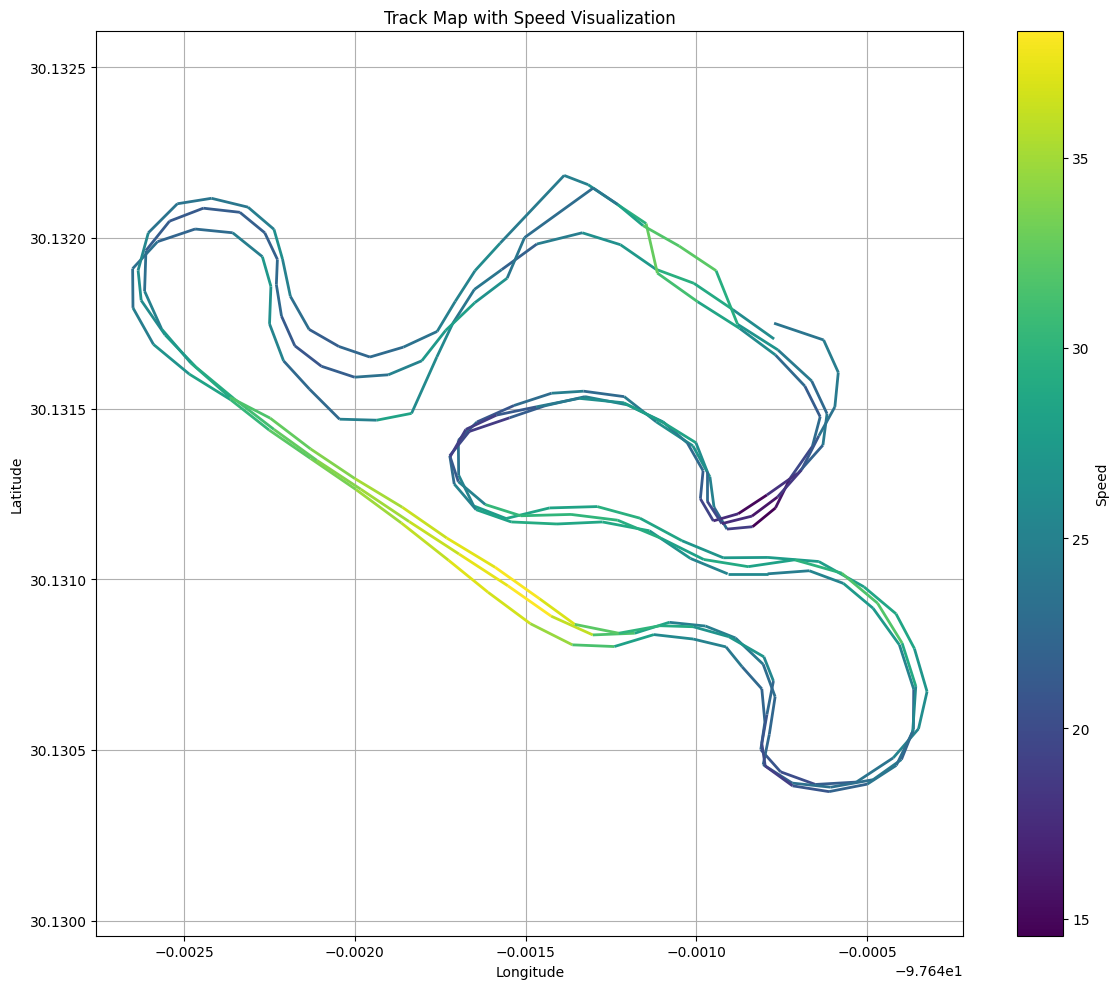

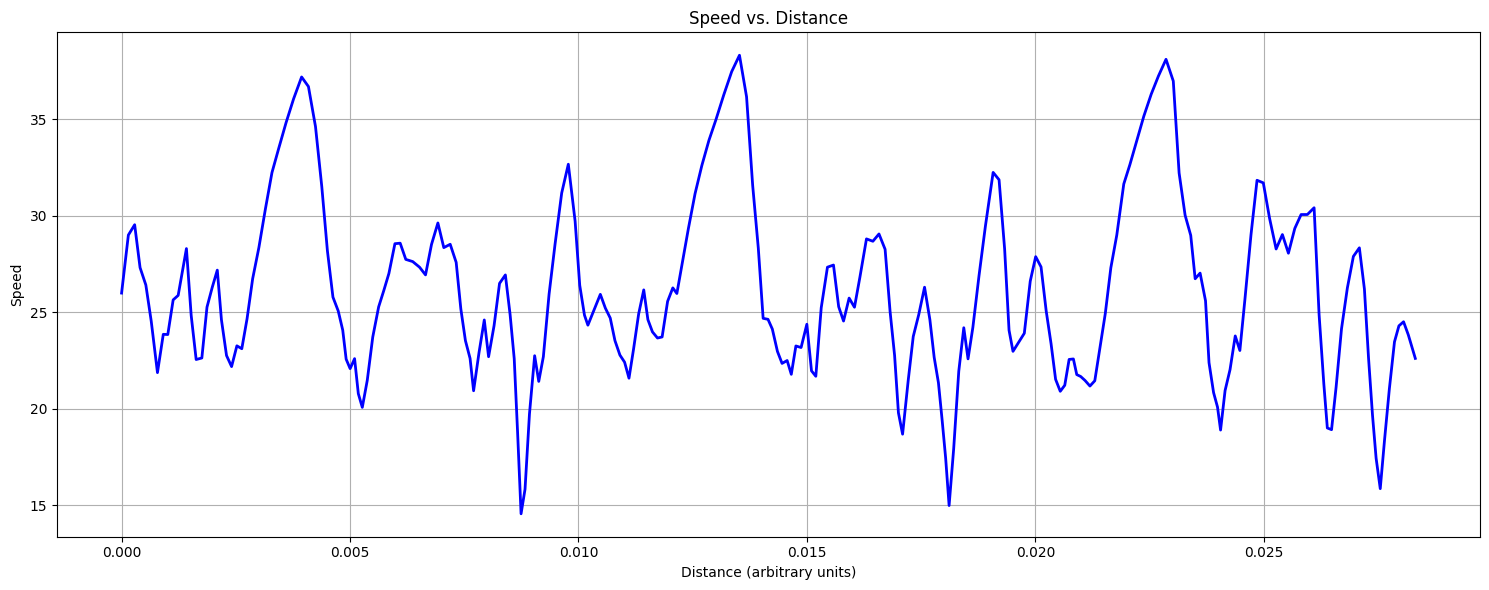

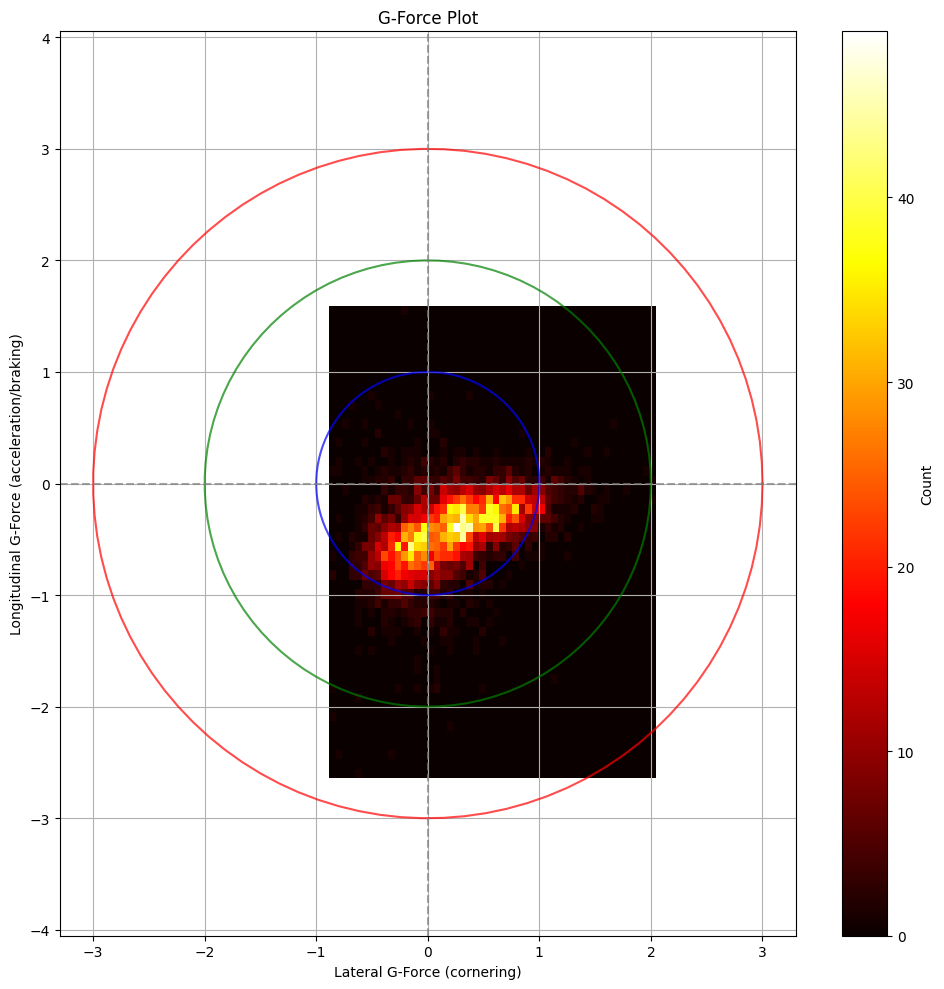

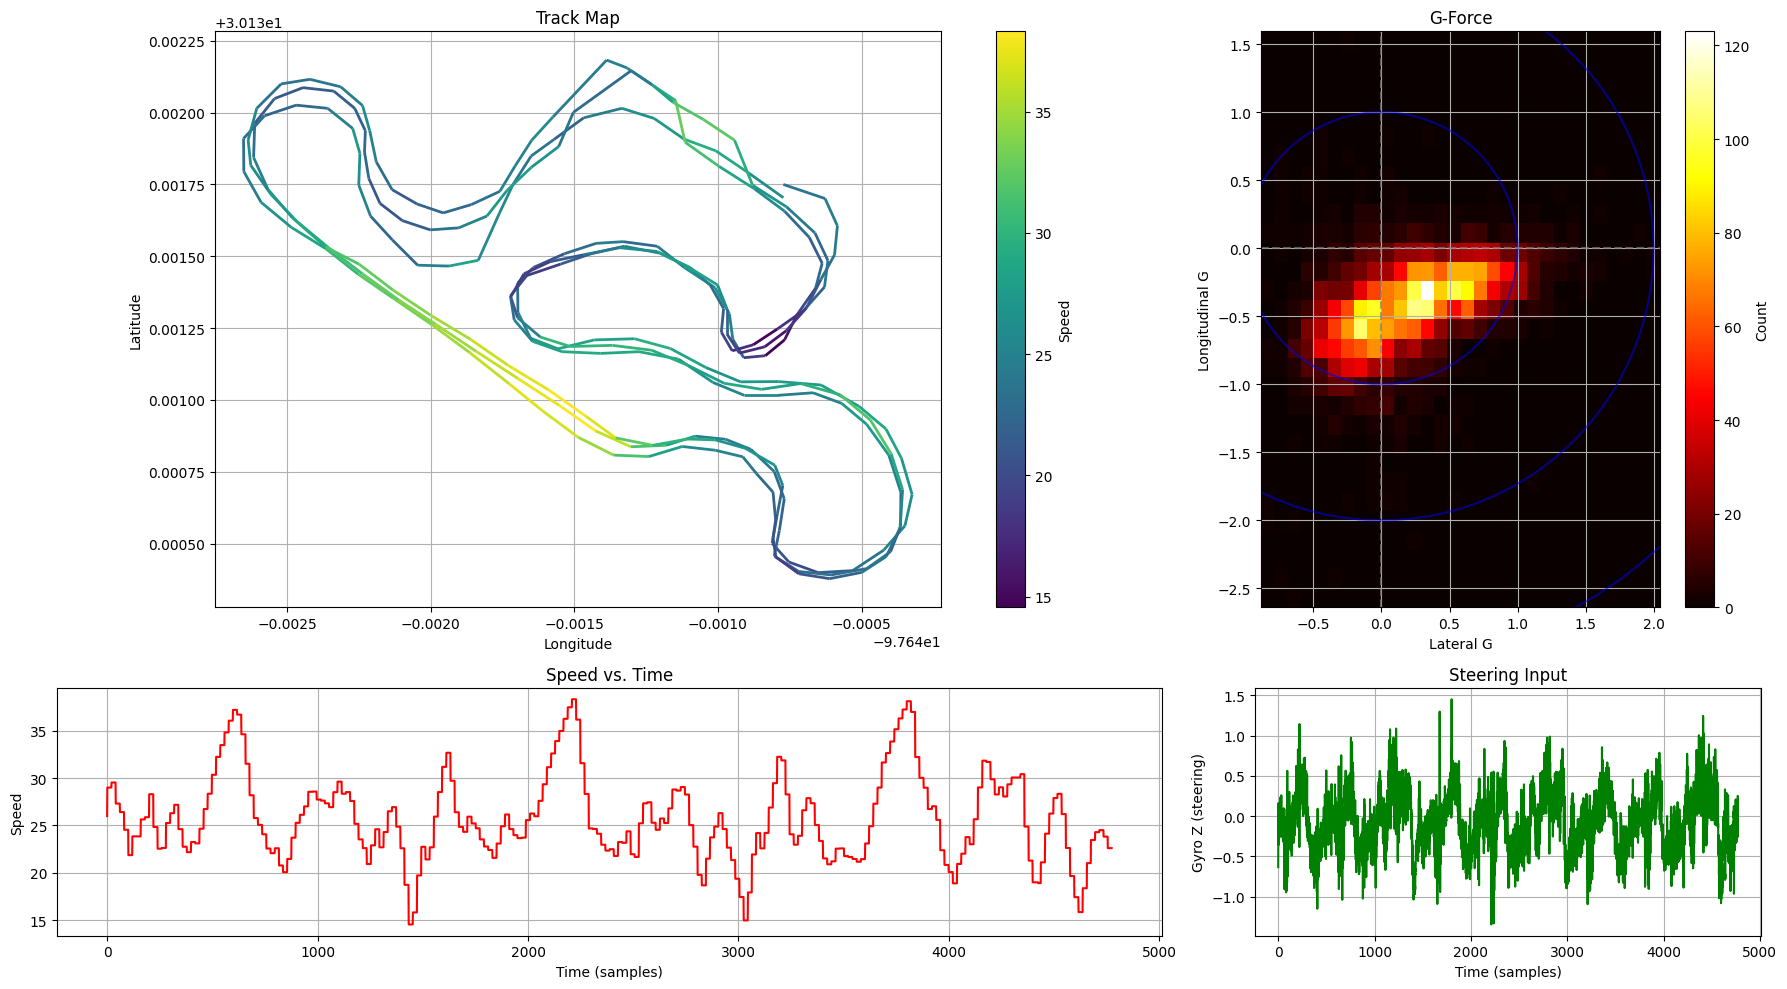

Found 20 complete laps
Identified 20 laps
Lap 1: 78.00 seconds
Lap 2: 0.00 seconds
Lap 3: 0.00 seconds
Lap 4: 0.00 seconds
Lap 5: 0.00 seconds
Lap 6: 0.00 seconds
Lap 7: 0.00 seconds
Lap 8: 0.00 seconds
Lap 9: 0.00 seconds
Lap 10: 0.00 seconds
Lap 11: 80.00 seconds
Lap 12: 0.00 seconds
Lap 13: 0.00 seconds
Lap 14: 0.00 seconds
Lap 15: 0.00 seconds
Lap 16: 0.00 seconds
Lap 17: 0.00 seconds
Lap 18: 0.00 seconds
Lap 19: 0.00 seconds
Lap 20: 0.00 seconds


In [75]:
# Call the functions to generate the analysis
plot_track_map_with_speed()
cum_distance = plot_speed_trace()
plot_gforce()
plot_telemetry_dashboard()

# Try to identify laps if possible
try:
    lap_indices, lap_times = identify_laps()
    print(f"Identified {len(lap_times)} laps")
    for i, lap_time in enumerate(lap_times):
        print(f"Lap {i+1}: {lap_time:.2f} seconds")
except Exception as e:
    print(f"Lap identification failed: {e}")